# NB_08B v4 — Fundamental News Sentiment Overlay corregido


## Motivo de esta versión

La versión v3 permitió ejecutar el flujo completo, pero al revisar los outputs se detectaron dos problemas metodológicos importantes:

1. La cache de noticias de compañía se reutilizaba desde una versión anterior, por lo que la ventana real seguía siendo corta aunque las variables se denominaran `30d_pre`.
2. La cache macro anterior devolvía cobertura nula y no se estaba forzando una descarga nueva por tópicos.

Esta versión corrige esos puntos y está pensada para ejecutarse en kernel limpio.

---

## Qué cambia en v4

- Define explícitamente `signals_for_news` desde `RF_TOP_30`.
- No reutiliza caches antiguas de GDELT para company/macro news.
- Crea caches nuevas `v4` y permite reanudar si ya existen.
- Descarga noticias de compañía en ventana `t-30 a t-1`.
- Descarga noticias macro por tópico en ventana `t-30 a t-1`.
- Mantiene cache de FinBERT solo por texto, porque eso no introduce sesgo temporal.
- Mantiene diagnóstico explícito de cobertura antes del backtest.

---

## Pregunta de investigación

> ¿El sentimiento fundamental/noticioso previo a una señal técnica + ML aporta información incremental para filtrar, modular o mejorar la estrategia `RandomForest_TOP_30`?

No se intenta demostrar que las noticias predicen el mercado.  
Se evalúa si el contexto noticioso previo puede funcionar como capa de riesgo.


In [1]:
# ============================================================
# 0. Instalación opcional de dependencias
# ============================================================

# Si falta alguna librería, cambia a True y ejecuta esta celda.
INSTALL_MISSING_PACKAGES = False

if INSTALL_MISSING_PACKAGES:
    import sys
    !{sys.executable} -m pip install -q requests tqdm transformers torch yfinance

In [2]:
# ============================================================
# 1. Imports, parámetros y rutas
# ============================================================

from pathlib import Path
import time
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Backtest
INITIAL_CAPITAL = 200_000.0
MAX_POSITIONS = 20

# Noticias
PRE_WINDOW_DAYS = 30
MAX_ARTICLES_COMPANY_PER_SIGNAL = 15
MAX_ARTICLES_MACRO_PER_TOPIC_DATE = 3
SLEEP_SECONDS_GDELT = 0.10

# Para prueba rápida: usar, por ejemplo, 100.
# Para ejecución completa: None.
MAX_SIGNALS_FOR_NEWS = None

ENABLE_MACRO_NEWS = True

# Control de cache GDELT
# False: si existe cache v4, la reutiliza.
# True: borra la cache v4 y descarga de nuevo.
FORCE_REDOWNLOAD_GDELT = False

# FinBERT
FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_BATCH_SIZE = 16

BASE_DIR = Path.cwd()

DATASET_PATH = BASE_DIR / "../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip"
PREDICTIONS_PATH = BASE_DIR / "../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip"
AUDIT_PATH = BASE_DIR / "../NB_05/df_nb04b2_v4_signal_trade_audit.csv"

OUTPUT_DIR = BASE_DIR / "outputs_nb08b_v4"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
EQUITY_DIR = FIG_DIR / "equity_curves"
DRAWDOWN_DIR = FIG_DIR / "drawdowns"
YEARLY_DIR = FIG_DIR / "yearly"

# Caches anteriores, si la versión previa se ejecutó en la misma carpeta
OLD_OUTPUT_DIR = BASE_DIR / "outputs_nb08b"
OLD_CACHE_DIR = OLD_OUTPUT_DIR / "cache"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR, EQUITY_DIR, DRAWDOWN_DIR, YEARLY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATASET_PATH:", DATASET_PATH, "->", DATASET_PATH.exists())
print("PREDICTIONS_PATH:", PREDICTIONS_PATH, "->", PREDICTIONS_PATH.exists())
print("AUDIT_PATH:", AUDIT_PATH, "->", AUDIT_PATH.exists())
print("OLD_CACHE_DIR:", OLD_CACHE_DIR, "->", OLD_CACHE_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

missing = [str(p) for p in [DATASET_PATH, PREDICTIONS_PATH, AUDIT_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError("No se encontraron archivos requeridos: " + " | ".join(missing))

BASE_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_08B
DATASET_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08B/../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip -> True
PREDICTIONS_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08B/../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip -> True
AUDIT_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08B/../NB_05/df_nb04b2_v4_signal_trade_audit.csv -> True
OLD_CACHE_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_08B/outputs_nb08b/cache -> True
OUTPUT_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_08B/outputs_nb08b_v4


## 2. Funciones auxiliares

La función más importante aquí es `normalize_signal_id`.

Evita que pandas trate como distintos:

```text
5050
5050.0
"5050"
"5050.0"
```

Todos pasan a:

```text
"5050"
```

In [3]:
# ============================================================
# 2. Funciones auxiliares
# ============================================================

def normalize_signal_id_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    # Si viene como notación numérica simple, intentar convertir a int
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s

def normalize_signal_id_column(df, col="signal_id"):
    if col in df.columns:
        df[col] = df[col].apply(normalize_signal_id_value).astype(str)
    return df

def clean_company_name(name):
    if pd.isna(name) or str(name).strip() == "":
        return None
    name = str(name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

def simplify_company_name(name):
    if name is None or pd.isna(name):
        return None

    s = str(name)
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"\bInc\.?\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bCorporation\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bCorp\.?\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bCompany\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bCo\.?\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bPLC\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bLtd\.?\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bLimited\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bClass\s+[A-Z]\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bCommon Stock\b", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\s+", " ", s).strip(" ,.-")

    return s if s else str(name).strip()

def safe_query_text(text):
    text = str(text).replace('"', " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def col_or_zero(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0)
    return pd.Series(0, index=df.index, dtype="float64")

def profit_factor_from_pnl(pnls):
    pnls = pd.Series(pnls).dropna()
    gains = pnls[pnls > 0].sum()
    losses = -pnls[pnls < 0].sum()
    if losses == 0:
        return np.inf if gains > 0 else np.nan
    return gains / losses

def max_drawdown_from_equity(equity):
    s = pd.Series(equity).astype(float)
    if s.empty:
        return np.nan
    return (s / s.cummax() - 1).min()

## 3. Carga de datos base y normalización

Se cargan:

- Dataset supervisado NB_05.
- Predicciones walk-forward NB_06B.
- Auditoría técnica de señales.

Luego se normaliza `signal_id` en todos los dataframes.

In [4]:
# ============================================================
# 3. Carga y normalización de datos base
# ============================================================

dataset = pd.read_csv(DATASET_PATH)
pred = pd.read_csv(PREDICTIONS_PATH)
audit = pd.read_csv(AUDIT_PATH)

audit = audit.rename(columns={
    "Ticker": "ticker",
    "Year": "signal_year",
    "ret_combo": "outcome_ret_combo",
    "ret_core": "outcome_ret_core",
    "ret_tactical": "outcome_ret_tactical",
})

for df in [dataset, pred, audit]:
    normalize_signal_id_column(df)
    for col in ["signal_date", "entry_date", "core_exit_date", "tactical_exit_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    if "ticker" in df.columns:
        df["ticker"] = df["ticker"].astype(str)

print("Dataset:", dataset.shape, "signal_id dtype:", dataset["signal_id"].dtype if "signal_id" in dataset.columns else "NA")
print("Pred:", pred.shape, "signal_id dtype:", pred["signal_id"].dtype)
print("Audit:", audit.shape, "signal_id dtype:", audit["signal_id"].dtype)

display(pred.head())
display(audit.head())

Dataset: (8155, 76) signal_id dtype: object
Pred: (13040, 13) signal_id dtype: object
Audit: (8155, 38) signal_id dtype: object


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1
0,4896,AMT,2023-01-03,2023-01-03,2023,1,0.0230,1,Dummy,1.0000,1,0.5000,1
1,4897,A,2023-01-04,2023-01-04,2023,0,-0.0018,1,Dummy,1.0000,1,0.5000,1
2,4898,ABT,2023-01-04,2023-01-04,2023,0,-0.0310,1,Dummy,1.0000,1,0.5000,1
3,4899,ADI,2023-01-04,2023-01-04,2023,1,0.1004,1,Dummy,1.0000,1,0.5000,1
4,4900,BDX,2023-01-04,2023-01-04,2023,0,-0.0720,1,Dummy,1.0000,1,0.5000,1


,signal_id,ticker,signal_year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,outcome_ret_tactical,outcome_ret_core,outcome_ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis
0,1,ALLE,2018,2018-04-16,2018-04-16,77.3274,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.2500,0.0255,1.0127,70.7483,64.1724,2018-04-26,71.1861,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.1861,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaN,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.0794,-0.0794,-0.0794,0.0196,-0.1156,-0.0961,8,8,78.8400,68.3872,fallo_sin_recorrido_mfe_menor_2pct
1,2,BF-B,2018,2018-04-16,2018-04-16,48.7357,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.5000,0.0182,1.2991,92.9632,88.9731,2018-05-25,50.3857,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.8747,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaN,2018-06-06,2018-04-17,2018-04-19,0.0339,-0.0587,-0.0124,0.0658,-0.0682,-0.0024,36,29,51.9440,45.4113,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
2,3,PGR,2018,2018-04-16,2018-04-16,48.0361,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0311,1.4822,62.8572,47.5003,2018-06-18,48.8087,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.4448,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.0161,-0.0123,0.0019,0.0630,-0.0463,0.0167,49,44,51.0635,45.8129,positive_or_flat
3,4,TECH,2018,2018-04-16,2018-04-16,35.9652,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.7500,0.0305,1.0450,78.7651,72.5172,2018-06-21,38.8970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.1287,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.0815,-0.0233,0.0291,0.1150,-0.0430,0.0720,51,47,40.1000,34.4204,positive_or_flat
4,5,TKO,2018,2018-04-16,2018-04-16,35.8697,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.5000,0.0604,1.4770,98.3573,92.1879,2018-08-08,72.0430,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.0430,MAX_HOLD_OR_DATA_END,False,NaN,NaN,NaN,2018-04-17,2018-06-01,1.0085,1.0085,1.0085,1.1808,-0.0304,1.1504,80,80,78.2242,34.7794,positive_or_flat


## 4. Reconstrucción de RF_TOP_30

Se reconstruye la estrategia base `RandomForest_TOP_30` desde las predicciones walk-forward.

In [5]:
# ============================================================
# 4. RF_TOP_30 por fold
# ============================================================

rf_pred = pred[pred["model"] == "RandomForest"].copy()
normalize_signal_id_column(rf_pred)

required = ["signal_id", "ticker", "entry_date", "signal_year", "fold", "score", "target_combo_positive", "outcome_ret_combo"]
missing = [c for c in required if c not in rf_pred.columns]
if missing:
    raise ValueError(f"Faltan columnas en rf_pred: {missing}")

rf_top30_parts = []
for fold, g in rf_pred.groupby("fold"):
    n = max(1, int(np.ceil(len(g) * 0.30)))
    rf_top30_parts.append(g.sort_values("score", ascending=False).head(n))

rf_top30 = pd.concat(rf_top30_parts, ignore_index=True)
normalize_signal_id_column(rf_top30)
rf_top30["strategy_base"] = "RF_TOP_30_BASE"

print("RF_TOP_30 señales candidatas:", rf_top30.shape)
display(rf_top30.groupby("signal_year")["signal_id"].count().to_frame("rf_top30_signals"))
display(rf_top30.head())

RF_TOP_30 señales candidatas: (980, 14)


,rf_top30_signals
signal_year,
2023,273
2024,429
2025,278


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1,strategy_base
0,5787,RCL,2023-12-19,2023-12-19,2023,0,-0.0606,1,RandomForest,0.6549,1,0.4250,1,RF_TOP_30_BASE
1,5769,EFX,2023-12-18,2023-12-18,2023,1,0.0425,1,RandomForest,0.6442,1,0.4250,1,RF_TOP_30_BASE
2,5798,EXPE,2023-12-21,2023-12-21,2023,0,-0.1515,1,RandomForest,0.6433,1,0.4250,1,RF_TOP_30_BASE
3,5797,CRH,2023-12-21,2023-12-21,2023,1,0.0982,1,RandomForest,0.6390,1,0.4250,1,RF_TOP_30_BASE
4,5783,PHM,2023-12-19,2023-12-19,2023,1,0.0278,1,RandomForest,0.6384,1,0.4250,1,RF_TOP_30_BASE


## 5. Nombres de compañía y términos de búsqueda

La versión anterior buscaba de forma demasiado restrictiva.  
Ahora se generan términos más simples:

- nombre completo;
- nombre simplificado;
- ticker como fallback.

Ejemplo:

```text
"The Home Depot, Inc." → "Home Depot"
"Apple Inc." → "Apple"
```

In [6]:
# ============================================================
# 5. Nombres de compañías
# ============================================================

ticker_name_cache_path = CACHE_DIR / "ticker_company_names_cache.csv"
old_ticker_name_cache_path = OLD_CACHE_DIR / "ticker_company_names_cache.csv"

def load_or_build_company_names(tickers):
    frames = []

    if ticker_name_cache_path.exists():
        frames.append(pd.read_csv(ticker_name_cache_path))

    if old_ticker_name_cache_path.exists():
        frames.append(pd.read_csv(old_ticker_name_cache_path))

    if frames:
        cached = pd.concat(frames, ignore_index=True).drop_duplicates("ticker")
    else:
        cached = pd.DataFrame(columns=["ticker", "company_name", "name_source"])

    cached["ticker"] = cached["ticker"].astype(str)
    missing_tickers = sorted(set(tickers) - set(cached["ticker"]))

    if missing_tickers:
        try:
            import yfinance as yf
            rows = []
            for ticker in tqdm(missing_tickers, desc="Descargando nombres yfinance"):
                company_name = None
                source = "ticker_fallback"
                try:
                    info = yf.Ticker(ticker).get_info()
                    company_name = info.get("shortName") or info.get("longName") or info.get("displayName")
                    company_name = clean_company_name(company_name)
                    if company_name:
                        source = "yfinance"
                except Exception:
                    company_name = None

                if not company_name:
                    company_name = ticker
                    source = "ticker_fallback"

                rows.append({"ticker": ticker, "company_name": company_name, "name_source": source})
                time.sleep(0.03)

            extra = pd.DataFrame(rows)
            cached = pd.concat([cached, extra], ignore_index=True).drop_duplicates("ticker")
        except Exception as e:
            print("No se pudo usar yfinance. Se usará ticker como fallback.", e)
            extra = pd.DataFrame({
                "ticker": missing_tickers,
                "company_name": missing_tickers,
                "name_source": "ticker_fallback"
            })
            cached = pd.concat([cached, extra], ignore_index=True).drop_duplicates("ticker")

    cached.to_csv(ticker_name_cache_path, index=False)
    return cached

selected_tickers = sorted(rf_top30["ticker"].dropna().astype(str).unique())
ticker_names = load_or_build_company_names(selected_tickers)

ticker_names["company_name"] = ticker_names["company_name"].apply(clean_company_name)
ticker_names["company_core_name"] = ticker_names["company_name"].apply(simplify_company_name)

display(ticker_names.head())
display(ticker_names["name_source"].value_counts().to_frame("count"))

rf_top30 = rf_top30.merge(ticker_names, on="ticker", how="left")
rf_top30["company_name"] = rf_top30["company_name"].fillna(rf_top30["ticker"])
rf_top30["company_core_name"] = rf_top30["company_core_name"].fillna(rf_top30["company_name"])

,ticker,company_name,name_source,company_core_name
0,A,"Agilent Technologies, Inc.",yfinance,Agilent Technologies
1,AAPL,Apple Inc.,yfinance,Apple
2,ABBV,AbbVie Inc.,yfinance,AbbVie
3,ABNB,"Airbnb, Inc.",yfinance,Airbnb
4,ACGL,Arch Capital Group Ltd.,yfinance,Arch Capital Group


,count
name_source,
yfinance,375


## 6. Descarga de noticias GDELT con cache v4

Esta versión descarga realmente:

- noticias por compañía en ventana `t-30 a t-1`;
- noticias macro por tópico en ventana `t-30 a t-1`.

No reutiliza la cache GDELT de versiones anteriores porque podía corresponder a otra ventana temporal.  
Solo reutiliza cache v4 si ya existe, para permitir reanudar ejecuciones.


In [7]:
# ============================================================
# 6. Funciones GDELT
# ============================================================

GDELT_DOC_API_URL = "https://api.gdeltproject.org/api/v2/doc/doc"

def gdelt_datetime(dt):
    dt = pd.to_datetime(dt)
    return dt.strftime("%Y%m%d%H%M%S")

def query_gdelt_articles(query, start_date, end_date, maxrecords=10):
    params = {
        "query": query,
        "mode": "ArtList",
        "format": "json",
        "startdatetime": gdelt_datetime(pd.to_datetime(start_date).replace(hour=0, minute=0, second=0)),
        "enddatetime": gdelt_datetime(pd.to_datetime(end_date).replace(hour=23, minute=59, second=59)),
        "maxrecords": int(maxrecords),
        "sort": "datedesc",
    }
    try:
        r = requests.get(GDELT_DOC_API_URL, params=params, timeout=30)
        if r.status_code != 200:
            return []
        data = r.json()
        return data.get("articles", [])
    except Exception:
        return []

def normalize_article(article, signal_id=None, ticker=None, entry_date=None, query_type=None, query=None, window_start=None, window_end=None):
    return {
        "signal_id": signal_id,
        "ticker": ticker,
        "entry_date": entry_date,
        "query_type": query_type,
        "query": query,
        "window_start": window_start,
        "window_end": window_end,
        "url": article.get("url"),
        "title": article.get("title"),
        "seendate": article.get("seendate"),
        "domain": article.get("domain"),
        "language": article.get("language"),
        "sourcecountry": article.get("sourceCountry") or article.get("sourcecountry"),
        "no_articles_found": False,
    }

def build_company_queries(company_name, company_core_name, ticker):
    terms = []

    for term in [company_core_name, company_name]:
        term = safe_query_text(term)
        if term and term.upper() != str(ticker).upper() and len(term) >= 3:
            terms.append(f'"{term}"')

    # fallback ticker + stock para evitar tickers demasiado ambiguos
    ticker = safe_query_text(ticker)
    if ticker and len(ticker) >= 3:
        terms.append(f'"{ticker}" stock')

    # Quitar duplicados conservando orden
    seen = set()
    out = []
    for q in terms:
        if q not in seen:
            out.append(q)
            seen.add(q)
    return out[:3]

MACRO_TOPICS = [
    '"Federal Reserve"',
    'inflation',
    'tariffs',
    '"interest rates"',
    'recession',
    '"trade war"',
    '"economic policy"',
    'Trump',
]

In [8]:
# ============================================================
# 7. Descargar company news GDELT v4
#    Ventana real t-30 a t-1, sin reutilizar cache antigua
# ============================================================

# Base explícita de señales para noticias
signals_for_news = rf_top30.copy()
normalize_signal_id_column(signals_for_news)
signals_for_news["entry_date"] = pd.to_datetime(signals_for_news["entry_date"], errors="coerce")

if MAX_SIGNALS_FOR_NEWS is not None:
    signals_for_news = (
        signals_for_news
        .sort_values(["fold", "score"], ascending=[True, False])
        .head(int(MAX_SIGNALS_FOR_NEWS))
        .copy()
    )

company_news_cache_path = CACHE_DIR / "gdelt_company_news_rf_top30_v4_cache.csv"

if FORCE_REDOWNLOAD_GDELT and company_news_cache_path.exists():
    company_news_cache_path.unlink()

if company_news_cache_path.exists():
    company_news_all = pd.read_csv(company_news_cache_path)
    normalize_signal_id_column(company_news_all)
    print("Company news cargadas desde cache v4:", company_news_cache_path)
else:
    rows = []

    for _, row in tqdm(signals_for_news.iterrows(), total=len(signals_for_news), desc="GDELT company news v4"):
        signal_id = normalize_signal_id_value(row.get("signal_id"))
        ticker = str(row.get("ticker"))
        entry_date = pd.to_datetime(row.get("entry_date"), errors="coerce")
        company_name = row.get("company_name")
        company_core_name = row.get("company_core_name")

        if pd.isna(entry_date):
            continue

        window_start = (entry_date - pd.Timedelta(days=PRE_WINDOW_DAYS)).strftime("%Y-%m-%d")
        window_end = (entry_date - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

        queries = build_company_queries(company_name, company_core_name, ticker)
        found_any = False

        for q in queries:
            articles = query_gdelt_articles(
                q,
                window_start,
                window_end,
                maxrecords=MAX_ARTICLES_COMPANY_PER_SIGNAL,
            )
            if articles:
                found_any = True
                for article in articles:
                    rows.append(normalize_article(
                        article,
                        signal_id=signal_id,
                        ticker=ticker,
                        entry_date=entry_date.strftime("%Y-%m-%d"),
                        query_type="company",
                        query=q,
                        window_start=window_start,
                        window_end=window_end,
                    ))
            time.sleep(SLEEP_SECONDS_GDELT)

        if not found_any:
            rows.append({
                "signal_id": signal_id,
                "ticker": ticker,
                "entry_date": entry_date.strftime("%Y-%m-%d"),
                "query_type": "company",
                "query": " | ".join(queries),
                "window_start": window_start,
                "window_end": window_end,
                "url": np.nan,
                "title": np.nan,
                "seendate": np.nan,
                "domain": np.nan,
                "language": np.nan,
                "sourcecountry": np.nan,
                "no_articles_found": True,
            })

    company_news_all = pd.DataFrame(rows)
    normalize_signal_id_column(company_news_all)

    dedup_cols = [
        "signal_id", "query_type", "url", "title", "window_start", "window_end"
    ]
    dedup_cols = [c for c in dedup_cols if c in company_news_all.columns]
    company_news_all = company_news_all.drop_duplicates(dedup_cols)
    company_news_all.to_csv(company_news_cache_path, index=False)
    print("Company news descargadas y guardadas en cache v4:", company_news_cache_path)

print("Shape company_news_all:", company_news_all.shape)
reales_company = company_news_all[company_news_all["no_articles_found"].fillna(False) == False]
print("Señales con al menos una noticia company:", reales_company["signal_id"].nunique() if not reales_company.empty else 0)
print("Filas reales con noticias company:", reales_company.shape[0])
print("Ventanas detectadas:")
display(company_news_all[["window_start", "window_end"]].drop_duplicates().head())
display(company_news_all.head())


Company news cargadas desde cache v4: /Users/rbr/TFM_MVP/JUNIO/NB_08B/outputs_nb08b_v4/cache/gdelt_company_news_rf_top30_v4_cache.csv
Shape company_news_all: (5711, 14)
Señales con al menos una noticia company: 335
Filas reales con noticias company: 5066
Ventanas detectadas:


,window_start,window_end
0,2023-11-19,2023-12-18
1,2023-11-18,2023-12-17
2,2023-11-21,2023-12-20
55,2023-11-13,2023-12-12
73,2023-11-15,2023-12-14


,signal_id,ticker,entry_date,query_type,query,window_start,window_end,url,title,seendate,domain,language,sourcecountry,no_articles_found
0,5787,RCL,2023-12-19,company,"""Royal Caribbean Cruises"" | ""Royal Caribbean C...",2023-11-19,2023-12-18,NaN,NaN,NaN,NaN,NaN,NaN,True
1,5769,EFX,2023-12-18,company,"""Equifax"" | ""Equifax, Inc."" | ""EFX"" stock",2023-11-18,2023-12-17,NaN,NaN,NaN,NaN,NaN,NaN,True
2,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.nbcdfw.com/news/business/money-rep...,"Booking , Agoda or Expedia ? A review of 200 ,...",20231221T233000Z,nbcdfw.com,English,United States,False
3,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.cnbc.com/2023/12/22/which-has-chea...,"Which has cheaper hotel rates : Booking , Agod...",20231221T233000Z,cnbc.com,English,United States,False
4,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.bnnbloomberg.ca/forget-the-top-5-t...,"Forget the Top 5 , These Stocks Were the Bigge...",20231221T201500Z,bnnbloomberg.ca,English,Canada,False


In [9]:
# ============================================================
# 8. Descargar macro news GDELT v4 por tópico
#    Ventana real t-30 a t-1, sin reutilizar cache antigua
# ============================================================

macro_news_cache_path = CACHE_DIR / "gdelt_macro_news_v4_cache.csv"

if FORCE_REDOWNLOAD_GDELT and macro_news_cache_path.exists():
    macro_news_cache_path.unlink()

if not ENABLE_MACRO_NEWS:
    print("ENABLE_MACRO_NEWS=False. Se continúa sin macro news.")
    macro_news_all = pd.DataFrame()
elif macro_news_cache_path.exists():
    macro_news_all = pd.read_csv(macro_news_cache_path)
    print("Macro news cargadas desde cache v4:", macro_news_cache_path)
else:
    macro_rows = []

    unique_dates = (
        signals_for_news[["entry_date"]]
        .dropna()
        .drop_duplicates()
        .sort_values("entry_date")
    )

    for _, row in tqdm(unique_dates.iterrows(), total=len(unique_dates), desc="GDELT macro news v4"):
        entry_date = pd.to_datetime(row["entry_date"], errors="coerce")
        if pd.isna(entry_date):
            continue

        entry_date_str = entry_date.strftime("%Y-%m-%d")
        window_start = (entry_date - pd.Timedelta(days=PRE_WINDOW_DAYS)).strftime("%Y-%m-%d")
        window_end = (entry_date - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

        found_any = False

        for topic in MACRO_TOPICS:
            q = topic
            articles = query_gdelt_articles(
                q,
                window_start,
                window_end,
                maxrecords=MAX_ARTICLES_MACRO_PER_TOPIC_DATE,
            )

            if articles:
                found_any = True
                for article in articles:
                    macro_rows.append(normalize_article(
                        article,
                        signal_id=np.nan,
                        ticker=np.nan,
                        entry_date=entry_date_str,
                        query_type="macro",
                        query=q,
                        window_start=window_start,
                        window_end=window_end,
                    ))
            time.sleep(SLEEP_SECONDS_GDELT)

        if not found_any:
            macro_rows.append({
                "signal_id": np.nan,
                "ticker": np.nan,
                "entry_date": entry_date_str,
                "query_type": "macro",
                "query": " | ".join(MACRO_TOPICS),
                "window_start": window_start,
                "window_end": window_end,
                "url": np.nan,
                "title": np.nan,
                "seendate": np.nan,
                "domain": np.nan,
                "language": np.nan,
                "sourcecountry": np.nan,
                "no_articles_found": True,
            })

    macro_news_all = pd.DataFrame(macro_rows)
    dedup_cols = [
        "entry_date", "query_type", "query", "url", "title", "window_start", "window_end"
    ]
    dedup_cols = [c for c in dedup_cols if c in macro_news_all.columns]
    macro_news_all = macro_news_all.drop_duplicates(dedup_cols)
    macro_news_all.to_csv(macro_news_cache_path, index=False)
    print("Macro news descargadas y guardadas en cache v4:", macro_news_cache_path)

print("Shape macro_news_all:", macro_news_all.shape)
if not macro_news_all.empty:
    reales_macro = macro_news_all[macro_news_all["no_articles_found"].fillna(False) == False]
    print("Fechas con macro real:", reales_macro["entry_date"].nunique() if not reales_macro.empty else 0)
    print("Filas reales macro:", reales_macro.shape[0])
    display(macro_news_all.head())
else:
    display(pd.DataFrame())


GDELT macro news v4:   0%|          | 0/296 [00:00<?, ?it/s]

Macro news descargadas y guardadas en cache v4: /Users/rbr/TFM_MVP/JUNIO/NB_08B/outputs_nb08b_v4/cache/gdelt_macro_news_v4_cache.csv
Shape macro_news_all: (1444, 14)
Fechas con macro real: 241
Filas reales macro: 1389


,signal_id,ticker,entry_date,query_type,query,window_start,window_end,url,title,seendate,domain,language,sourcecountry,no_articles_found
0,NaN,NaN,2023-01-04,macro,"""economic policy""",2022-12-05,2023-01-03,https://www.brasil247.com/blog/40-anos-em-4-8y...,40 anos em 4 - Paulo Kliass,20230104T234500Z,brasil247.com,Portuguese,Brazil,False
1,NaN,NaN,2023-01-04,macro,"""economic policy""",2022-12-05,2023-01-03,https://www.brasil247.com/blog/bons-e-novos-te...,Bons e novos tempos - Jorge Luiz Souto Maior,20230104T234500Z,brasil247.com,Portuguese,Brazil,False
2,NaN,NaN,2023-01-04,macro,"""economic policy""",2022-12-05,2023-01-03,https://www.brinknews.com/5-elections-to-watch...,5 Elections to Watch in 2023,20230104T233000Z,brinknews.com,English,China,False
3,NaN,NaN,2023-01-06,macro,"""Federal Reserve"" | inflation | tariffs | ""int...",2022-12-07,2023-01-05,NaN,NaN,NaN,NaN,NaN,NaN,True
4,NaN,NaN,2023-01-10,macro,"""Federal Reserve"" | inflation | tariffs | ""int...",2022-12-11,2023-01-09,NaN,NaN,NaN,NaN,NaN,NaN,True


## 7. FinBERT

Se clasifica el sentimiento de titulares con FinBERT.  
El resultado se cachea por texto para evitar repetir clasificación.

In [10]:
# ============================================================
# 9. Carga de FinBERT
# ============================================================

try:
    from transformers import pipeline
except Exception as e:
    raise ImportError(
        "No se pudo importar transformers. Cambia INSTALL_MISSING_PACKAGES=True en la primera celda y vuelve a ejecutar."
    ) from e

print("Cargando FinBERT:", FINBERT_MODEL_NAME)
finbert = pipeline(
    "text-classification",
    model=FINBERT_MODEL_NAME,
    tokenizer=FINBERT_MODEL_NAME,
    truncation=True,
    max_length=128,
    device=-1
)
print("FinBERT cargado correctamente.")

2026-06-21 13:10:36.604952: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Cargando FinBERT: ProsusAI/finbert


Device set to use cpu


FinBERT cargado correctamente.


In [11]:
# ============================================================
# 10. Preparar corpus para FinBERT
# ============================================================

def prepare_news_for_finbert(company_news, macro_news):
    frames = []

    if company_news is not None and not company_news.empty:
        c = company_news.copy()
        c["news_scope"] = "company"
        frames.append(c)

    if macro_news is not None and not macro_news.empty:
        m = macro_news.copy()
        m["news_scope"] = "macro"
        frames.append(m)

    if not frames:
        return pd.DataFrame()

    news = pd.concat(frames, ignore_index=True, sort=False)

    if "no_articles_found" not in news.columns:
        news["no_articles_found"] = False

    news = news[news["no_articles_found"].fillna(False) == False].copy()
    news["title"] = news["title"].astype(str)
    news = news[
        (~news["title"].isna()) &
        (news["title"].str.lower() != "none") &
        (news["title"].str.strip() != "")
    ].copy()

    news["text_for_finbert"] = news["title"].str.strip()
    normalize_signal_id_column(news)
    news = news.drop_duplicates(["news_scope", "url", "title", "entry_date", "signal_id"])
    return news.reset_index(drop=True)

news_for_finbert = prepare_news_for_finbert(company_news_all, macro_news_all)

print("Noticias reales para FinBERT:", news_for_finbert.shape)
display(news_for_finbert.head())

news_for_finbert.to_csv(OUTPUT_DIR / "news_raw_gdelt_for_finbert_nb08b_v4.csv", index=False)

Noticias reales para FinBERT: (6411, 16)


,signal_id,ticker,entry_date,query_type,query,window_start,window_end,url,title,seendate,domain,language,sourcecountry,no_articles_found,news_scope,text_for_finbert
0,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.nbcdfw.com/news/business/money-rep...,"Booking , Agoda or Expedia ? A review of 200 ,...",20231221T233000Z,nbcdfw.com,English,United States,False,company,"Booking , Agoda or Expedia ? A review of 200 ,..."
1,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.cnbc.com/2023/12/22/which-has-chea...,"Which has cheaper hotel rates : Booking , Agod...",20231221T233000Z,cnbc.com,English,United States,False,company,"Which has cheaper hotel rates : Booking , Agod..."
2,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.bnnbloomberg.ca/forget-the-top-5-t...,"Forget the Top 5 , These Stocks Were the Bigge...",20231221T201500Z,bnnbloomberg.ca,English,Canada,False,company,"Forget the Top 5 , These Stocks Were the Bigge..."
3,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://techcrunch.com/2023/12/21/tech-layoffs...,A comprehensive list of 2023 tech layoffs,20231221T184500Z,techcrunch.com,English,United States,False,company,A comprehensive list of 2023 tech layoffs
4,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.wired.com/story/airbnb-new-york-ba...,New York Airbnb Ban Is Causing a Christmas Crunch,20231220T171500Z,wired.com,English,United States,False,company,New York Airbnb Ban Is Causing a Christmas Crunch


In [12]:
# ============================================================
# 11. Clasificar sentimiento con cache
# ============================================================

finbert_cache_path = CACHE_DIR / "finbert_news_sentiment_v4_cache.csv"
old_finbert_cache_path = OLD_CACHE_DIR / "finbert_news_sentiment_cache.csv"
old_finbert_v3_cache_path = BASE_DIR / "outputs_nb08b_v3" / "cache" / "finbert_news_sentiment_v3_cache.csv"

cache_frames = []
if finbert_cache_path.exists():
    cache_frames.append(pd.read_csv(finbert_cache_path))
if old_finbert_cache_path.exists():
    cache_frames.append(pd.read_csv(old_finbert_cache_path))
if old_finbert_v3_cache_path.exists():
    cache_frames.append(pd.read_csv(old_finbert_v3_cache_path))

if cache_frames:
    finbert_cached = pd.concat(cache_frames, ignore_index=True, sort=False).drop_duplicates("text_for_finbert")
else:
    finbert_cached = pd.DataFrame(columns=[
        "text_for_finbert", "sentiment_label", "sentiment_confidence",
        "sentiment_numeric", "negative_confidence", "positive_confidence"
    ])

cached_texts = set(finbert_cached["text_for_finbert"].astype(str))
to_classify = news_for_finbert[~news_for_finbert["text_for_finbert"].astype(str).isin(cached_texts)].copy()

print("Textos ya clasificados:", len(cached_texts))
print("Textos nuevos a clasificar:", len(to_classify))

sent_rows = []
texts = to_classify["text_for_finbert"].astype(str).tolist()

for i in tqdm(range(0, len(texts), FINBERT_BATCH_SIZE), desc="FinBERT sentiment"):
    batch = texts[i:i+FINBERT_BATCH_SIZE]
    outputs = finbert(batch)
    for text, out in zip(batch, outputs):
        label = str(out["label"]).lower()
        confidence = float(out["score"])

        if "positive" in label:
            numeric = 1
        elif "negative" in label:
            numeric = -1
        else:
            numeric = 0

        sent_rows.append({
            "text_for_finbert": text,
            "sentiment_label": label,
            "sentiment_confidence": confidence,
            "sentiment_numeric": numeric,
            "negative_confidence": confidence if numeric == -1 else 0.0,
            "positive_confidence": confidence if numeric == 1 else 0.0,
        })

new_sent = pd.DataFrame(sent_rows)

if not new_sent.empty:
    finbert_all = pd.concat([finbert_cached, new_sent], ignore_index=True, sort=False).drop_duplicates("text_for_finbert")
else:
    finbert_all = finbert_cached.copy()

finbert_all.to_csv(finbert_cache_path, index=False)

news_sentiment = news_for_finbert.merge(finbert_all, on="text_for_finbert", how="left")
normalize_signal_id_column(news_sentiment)

print("Noticias clasificadas:", news_sentiment.shape)
display(news_sentiment["sentiment_label"].value_counts(dropna=False).to_frame("count"))
display(news_sentiment.head())

news_sentiment.to_csv(OUTPUT_DIR / "news_sentiment_finbert_nb08b_v4.csv", index=False)

Textos ya clasificados: 100
Textos nuevos a clasificar: 6359


FinBERT sentiment:   0%|          | 0/398 [00:00<?, ?it/s]

Noticias clasificadas: (6411, 21)


,count
sentiment_label,
neutral,4148
positive,1243
negative,1020


,signal_id,ticker,entry_date,query_type,query,window_start,window_end,url,title,seendate,domain,language,sourcecountry,no_articles_found,news_scope,text_for_finbert,sentiment_label,sentiment_confidence,sentiment_numeric,negative_confidence,positive_confidence
0,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.nbcdfw.com/news/business/money-rep...,"Booking , Agoda or Expedia ? A review of 200 ,...",20231221T233000Z,nbcdfw.com,English,United States,False,company,"Booking , Agoda or Expedia ? A review of 200 ,...",neutral,0.9174,0,0.0000,0.0000
1,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.cnbc.com/2023/12/22/which-has-chea...,"Which has cheaper hotel rates : Booking , Agod...",20231221T233000Z,cnbc.com,English,United States,False,company,"Which has cheaper hotel rates : Booking , Agod...",neutral,0.9333,0,0.0000,0.0000
2,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.bnnbloomberg.ca/forget-the-top-5-t...,"Forget the Top 5 , These Stocks Were the Bigge...",20231221T201500Z,bnnbloomberg.ca,English,Canada,False,company,"Forget the Top 5 , These Stocks Were the Bigge...",neutral,0.6598,0,0.0000,0.0000
3,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://techcrunch.com/2023/12/21/tech-layoffs...,A comprehensive list of 2023 tech layoffs,20231221T184500Z,techcrunch.com,English,United States,False,company,A comprehensive list of 2023 tech layoffs,negative,0.7386,-1,0.7386,0.0000
4,5798,EXPE,2023-12-21,company,"""Expedia Group""",2023-11-21,2023-12-20,https://www.wired.com/story/airbnb-new-york-ba...,New York Airbnb Ban Is Causing a Christmas Crunch,20231220T171500Z,wired.com,English,United States,False,company,New York Airbnb Ban Is Causing a Christmas Crunch,negative,0.9468,-1,0.9468,0.0000


## 8. Features de noticias por señal

Se agregan las noticias por señal:

- company news por `signal_id`;
- macro news por `entry_date`.

Luego se calcula un `Fundamental News Risk Score`.

In [13]:
# ============================================================
# 12. Agregación de noticias por señal
# ============================================================

# Base: todas las señales RF_TOP_30
news_features = signals_for_news.copy()
normalize_signal_id_column(news_features)
news_features["entry_date_key"] = pd.to_datetime(news_features["entry_date"], errors="coerce").dt.strftime("%Y-%m-%d")

# -----------------------
# Company features
# -----------------------
company_sent = news_sentiment[news_sentiment["news_scope"] == "company"].copy()
normalize_signal_id_column(company_sent)

if not company_sent.empty:
    company_features = (
        company_sent
        .groupby("signal_id")
        .agg(
            company_news_count_30d_pre=("title", "count"),
            company_negative_count_30d_pre=("sentiment_numeric", lambda x: (x == -1).sum()),
            company_positive_count_30d_pre=("sentiment_numeric", lambda x: (x == 1).sum()),
            company_neutral_count_30d_pre=("sentiment_numeric", lambda x: (x == 0).sum()),
            company_sentiment_mean_30d_pre=("sentiment_numeric", "mean"),
            company_sentiment_min_30d_pre=("sentiment_numeric", "min"),
            company_sentiment_conf_mean_30d_pre=("sentiment_confidence", "mean"),
            company_max_negative_conf_30d_pre=("negative_confidence", "max"),
        )
        .reset_index()
    )
else:
    company_features = pd.DataFrame(columns=["signal_id"])

normalize_signal_id_column(company_features)
news_features = news_features.merge(company_features, on="signal_id", how="left")

for c in ["company_news_count_30d_pre", "company_negative_count_30d_pre", "company_positive_count_30d_pre", "company_neutral_count_30d_pre"]:
    news_features[c] = col_or_zero(news_features, c)

news_features["company_negative_ratio_30d_pre"] = np.where(
    news_features["company_news_count_30d_pre"] > 0,
    news_features["company_negative_count_30d_pre"] / news_features["company_news_count_30d_pre"],
    np.nan
)

# -----------------------
# Macro features
# -----------------------
macro_sent = news_sentiment[news_sentiment["news_scope"] == "macro"].copy()

if not macro_sent.empty:
    macro_sent["entry_date_key"] = pd.to_datetime(macro_sent["entry_date"], errors="coerce").dt.strftime("%Y-%m-%d")
    macro_features = (
        macro_sent
        .groupby("entry_date_key")
        .agg(
            macro_news_count_30d_pre=("title", "count"),
            macro_negative_count_30d_pre=("sentiment_numeric", lambda x: (x == -1).sum()),
            macro_positive_count_30d_pre=("sentiment_numeric", lambda x: (x == 1).sum()),
            macro_neutral_count_30d_pre=("sentiment_numeric", lambda x: (x == 0).sum()),
            macro_sentiment_mean_30d_pre=("sentiment_numeric", "mean"),
            macro_sentiment_min_30d_pre=("sentiment_numeric", "min"),
            macro_sentiment_conf_mean_30d_pre=("sentiment_confidence", "mean"),
            macro_max_negative_conf_30d_pre=("negative_confidence", "max"),
        )
        .reset_index()
    )
else:
    macro_features = pd.DataFrame(columns=["entry_date_key"])

news_features = news_features.merge(macro_features, on="entry_date_key", how="left")

for c in ["macro_news_count_30d_pre", "macro_negative_count_30d_pre", "macro_positive_count_30d_pre", "macro_neutral_count_30d_pre"]:
    news_features[c] = col_or_zero(news_features, c)

news_features["macro_negative_ratio_30d_pre"] = np.where(
    news_features["macro_news_count_30d_pre"] > 0,
    news_features["macro_negative_count_30d_pre"] / news_features["macro_news_count_30d_pre"],
    np.nan
)

# -----------------------
# Total features
# -----------------------
news_features["total_news_count_30d_pre"] = (
    col_or_zero(news_features, "company_news_count_30d_pre")
    + col_or_zero(news_features, "macro_news_count_30d_pre")
)

news_features["total_negative_count_30d_pre"] = (
    col_or_zero(news_features, "company_negative_count_30d_pre")
    + col_or_zero(news_features, "macro_negative_count_30d_pre")
)

news_features["total_negative_ratio_30d_pre"] = np.where(
    news_features["total_news_count_30d_pre"] > 0,
    news_features["total_negative_count_30d_pre"] / news_features["total_news_count_30d_pre"],
    np.nan
)

news_features.to_csv(TABLE_DIR / "news_signal_features_nb08b_v4.csv", index=False)

print("Cobertura de noticias RF_TOP_30:")
print("Señales RF_TOP_30:", news_features["signal_id"].nunique())
print("Con company news:", int((news_features["company_news_count_30d_pre"] > 0).sum()))
print("Con macro news:", int((news_features["macro_news_count_30d_pre"] > 0).sum()))
print("Con cualquier news:", int((news_features["total_news_count_30d_pre"] > 0).sum()))

display(news_features.head())

Cobertura de noticias RF_TOP_30:
Señales RF_TOP_30: 980
Con company news: 335
Con macro news: 848
Con cualquier news: 904


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1,strategy_base,company_name,name_source,company_core_name,entry_date_key,company_news_count_30d_pre,company_negative_count_30d_pre,company_positive_count_30d_pre,company_neutral_count_30d_pre,company_sentiment_mean_30d_pre,company_sentiment_min_30d_pre,company_sentiment_conf_mean_30d_pre,company_max_negative_conf_30d_pre,company_negative_ratio_30d_pre,macro_news_count_30d_pre,macro_negative_count_30d_pre,macro_positive_count_30d_pre,macro_neutral_count_30d_pre,macro_sentiment_mean_30d_pre,macro_sentiment_min_30d_pre,macro_sentiment_conf_mean_30d_pre,macro_max_negative_conf_30d_pre,macro_negative_ratio_30d_pre,total_news_count_30d_pre,total_negative_count_30d_pre,total_negative_ratio_30d_pre
0,5787,RCL,2023-12-19,2023-12-19,2023,0,-0.0606,1,RandomForest,0.6549,1,0.4250,1,RF_TOP_30_BASE,Royal Caribbean Cruises Ltd.,yfinance,Royal Caribbean Cruises,2023-12-19,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,9.0000,1.0000,2.0000,6.0000,0.1111,-1.0000,0.6709,0.6291,0.1111,9.0000,1.0000,0.1111
1,5769,EFX,2023-12-18,2023-12-18,2023,1,0.0425,1,RandomForest,0.6442,1,0.4250,1,RF_TOP_30_BASE,"Equifax, Inc.",yfinance,Equifax,2023-12-18,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,3.0000,0.0000,0.0000,3.0000,0.0000,0.0000,0.8500,0.0000,0.0000,3.0000,0.0000,0.0000
2,5798,EXPE,2023-12-21,2023-12-21,2023,0,-0.1515,1,RandomForest,0.6433,1,0.4250,1,RF_TOP_30_BASE,"Expedia Group, Inc.",yfinance,Expedia Group,2023-12-21,15.0000,4.0000,0.0000,11.0000,-0.2667,-1.0000,0.8837,0.9708,0.2667,3.0000,0.0000,0.0000,3.0000,0.0000,0.0000,0.8037,0.0000,0.0000,18.0000,4.0000,0.2222
3,5797,CRH,2023-12-21,2023-12-21,2023,1,0.0982,1,RandomForest,0.6390,1,0.4250,1,RF_TOP_30_BASE,CRH PLC,yfinance,CRH,2023-12-21,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,3.0000,0.0000,0.0000,3.0000,0.0000,0.0000,0.8037,0.0000,0.0000,3.0000,0.0000,0.0000
4,5783,PHM,2023-12-19,2023-12-19,2023,1,0.0278,1,RandomForest,0.6384,1,0.4250,1,RF_TOP_30_BASE,"PulteGroup, Inc.",yfinance,PulteGroup,2023-12-19,20.0000,4.0000,3.0000,13.0000,-0.0500,-1.0000,0.8938,0.9503,0.2000,9.0000,1.0000,2.0000,6.0000,0.1111,-1.0000,0.6709,0.6291,0.1111,29.0000,5.0000,0.1724


In [14]:
# ============================================================
# 13. Fundamental News Risk Score
# ============================================================

nf = news_features.copy()
normalize_signal_id_column(nf)

nf["has_company_news"] = nf["company_news_count_30d_pre"].fillna(0) > 0
nf["has_macro_news"] = nf["macro_news_count_30d_pre"].fillna(0) > 0
nf["has_any_news"] = nf["total_news_count_30d_pre"].fillna(0) > 0

# Componentes de riesgo exclusivamente noticiosos
nf["risk_news_volume"] = nf["total_news_count_30d_pre"].rank(pct=True).fillna(0)
nf["risk_negative_ratio"] = nf["total_negative_ratio_30d_pre"].fillna(0)

max_neg_cols = [c for c in ["company_max_negative_conf_30d_pre", "macro_max_negative_conf_30d_pre"] if c in nf.columns]
if max_neg_cols:
    nf["risk_max_negative_conf"] = nf[max_neg_cols].max(axis=1).fillna(0)
else:
    nf["risk_max_negative_conf"] = 0.0

sent_cols = [c for c in ["company_sentiment_mean_30d_pre", "macro_sentiment_mean_30d_pre"] if c in nf.columns]
if sent_cols:
    sent_mean = nf[sent_cols].mean(axis=1)
    nf["risk_sentiment_mean_negative"] = ((-sent_mean).clip(lower=-1, upper=1) + 1) / 2
    nf["risk_sentiment_mean_negative"] = nf["risk_sentiment_mean_negative"].fillna(0.0)
else:
    nf["risk_sentiment_mean_negative"] = 0.0

nf["risk_macro_negative_ratio"] = nf["macro_negative_ratio_30d_pre"].fillna(0)

news_weights = {
    "risk_negative_ratio": 0.30,
    "risk_max_negative_conf": 0.20,
    "risk_news_volume": 0.15,
    "risk_sentiment_mean_negative": 0.20,
    "risk_macro_negative_ratio": 0.15,
}

nf["fundamental_news_risk_score"] = 0.0
for c, w in news_weights.items():
    nf["fundamental_news_risk_score"] += pd.to_numeric(nf[c], errors="coerce").fillna(0) * w

nf["fundamental_news_risk_bucket"] = "NO_NEWS"

mask_news = nf["has_any_news"] == True
if mask_news.sum() > 0:
    score_news = nf.loc[mask_news, "fundamental_news_risk_score"]
    if score_news.nunique() >= 4:
        nf.loc[mask_news, "fundamental_news_risk_bucket"] = pd.qcut(
            score_news,
            q=[0, 0.50, 0.75, 0.90, 1.00],
            labels=["LOW", "MEDIUM", "HIGH", "EXTREME"],
            duplicates="drop"
        ).astype(str)
    else:
        nf.loc[mask_news, "fundamental_news_risk_bucket"] = "LOW"

nf.to_csv(TABLE_DIR / "fundamental_news_risk_score_nb08b_v4.csv", index=False)

display(nf["fundamental_news_risk_bucket"].value_counts(dropna=False).to_frame("signals"))
display(nf[[
    "signal_id", "ticker", "entry_date", "total_news_count_30d_pre",
    "total_negative_count_30d_pre", "total_negative_ratio_30d_pre",
    "fundamental_news_risk_score", "fundamental_news_risk_bucket"
]].head())

,signals
fundamental_news_risk_bucket,
LOW,456
MEDIUM,223
HIGH,134
EXTREME,91
NO_NEWS,76


,signal_id,ticker,entry_date,total_news_count_30d_pre,total_negative_count_30d_pre,total_negative_ratio_30d_pre,fundamental_news_risk_score,fundamental_news_risk_bucket
0,5787,RCL,2023-12-19,9.0000,1.0000,0.1111,0.3557,LOW
1,5769,EFX,2023-12-18,3.0000,0.0000,0.0000,0.1266,LOW
2,5798,EXPE,2023-12-21,18.0000,4.0000,0.2222,0.4905,MEDIUM
3,5797,CRH,2023-12-21,3.0000,0.0000,0.0000,0.1266,LOW
4,5783,PHM,2023-12-19,29.0000,5.0000,0.1724,0.5026,MEDIUM


## 9. Evaluación signal-level

Se analiza si los buckets noticiosos tienen relación con la calidad posterior de las señales.

In [15]:
# ============================================================
# 14. Evaluación signal-level por bucket fundamental
# ============================================================

signal_news_eval = nf.copy()
signal_news_eval["target_combo_positive"] = pd.to_numeric(signal_news_eval["target_combo_positive"], errors="coerce")
signal_news_eval["outcome_ret_combo"] = pd.to_numeric(signal_news_eval["outcome_ret_combo"], errors="coerce")

news_bucket_metrics = (
    signal_news_eval
    .groupby("fundamental_news_risk_bucket")
    .agg(
        n_signals=("signal_id", "nunique"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
        p25_return=("outcome_ret_combo", lambda x: x.quantile(0.25)),
        p75_return=("outcome_ret_combo", lambda x: x.quantile(0.75)),
        avg_news_count=("total_news_count_30d_pre", "mean"),
        avg_negative_ratio=("total_negative_ratio_30d_pre", "mean"),
        avg_news_risk_score=("fundamental_news_risk_score", "mean"),
    )
    .reset_index()
)

display(news_bucket_metrics)
news_bucket_metrics.to_csv(TABLE_DIR / "news_bucket_signal_quality_nb08b_v4.csv", index=False)

news_bucket_yearly = (
    signal_news_eval
    .groupby(["signal_year", "fundamental_news_risk_bucket"])
    .agg(
        n_signals=("signal_id", "nunique"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
    )
    .reset_index()
)

display(news_bucket_yearly)
news_bucket_yearly.to_csv(TABLE_DIR / "news_bucket_signal_quality_by_year_nb08b_v4.csv", index=False)

,fundamental_news_risk_bucket,n_signals,success_rate,mean_return,median_return,p25_return,p75_return,avg_news_count,avg_negative_ratio,avg_news_risk_score
0,EXTREME,91,0.6044,0.0374,0.0298,-0.0424,0.0937,8.9011,0.6175,0.6943
1,HIGH,134,0.5672,0.0367,0.0221,-0.0507,0.1021,15.8731,0.2751,0.5357
2,LOW,456,0.6338,0.0658,0.0347,-0.0372,0.1149,8.0987,0.0591,0.2482
3,MEDIUM,223,0.5336,0.0185,0.0118,-0.0603,0.0776,14.4170,0.1721,0.4595
4,NO_NEWS,76,0.5789,0.0746,0.0146,-0.0743,0.1176,0.0000,NaN,0.0059


,signal_year,fundamental_news_risk_bucket,n_signals,success_rate,mean_return,median_return
0,2023,EXTREME,24,0.5417,0.0094,0.0071
1,2023,HIGH,47,0.5745,0.0354,0.0273
2,2023,LOW,135,0.6222,0.0434,0.0353
3,2023,MEDIUM,49,0.5102,0.0196,0.0012
4,2023,NO_NEWS,18,0.3889,-0.0068,-0.0145
5,2024,EXTREME,47,0.5957,0.0377,0.0298
6,2024,HIGH,47,0.5745,0.0235,0.0141
7,2024,LOW,211,0.6540,0.0590,0.0380
8,2024,MEDIUM,103,0.5922,0.0218,0.0207
9,2024,NO_NEWS,21,0.6667,0.0397,0.0204


## 10. Estrategias con overlay noticioso

Se evalúan reglas sobre RF_TOP_30:

- excluir riesgo noticioso extremo;
- excluir riesgo alto/extremo;
- excluir ratio negativo >= 50%;
- estrategia adaptativa según riesgo.

In [16]:
# ============================================================
# 15. Estrategias con overlay noticioso
# ============================================================

# Preparación robusta
nf_news = nf.copy()
rf_top30_news = rf_top30.copy()
rf_full = rf_pred.copy()
pred_news = pred.copy()

for df in [nf_news, rf_top30_news, rf_full, pred_news]:
    normalize_signal_id_column(df)

news_merge_cols = [
    "signal_id",
    "fundamental_news_risk_score",
    "fundamental_news_risk_bucket",
    "total_news_count_30d_pre",
    "total_negative_count_30d_pre",
    "total_negative_ratio_30d_pre",
    "company_news_count_30d_pre",
    "macro_news_count_30d_pre",
]

for c in news_merge_cols:
    if c not in nf_news.columns:
        nf_news[c] = "NO_NEWS" if c == "fundamental_news_risk_bucket" else 0

nf_news = nf_news.drop_duplicates("signal_id")

# RF_TOP_30 con noticias
rf_with_news = rf_top30_news.merge(nf_news[news_merge_cols], on="signal_id", how="left")
rf_with_news["fundamental_news_risk_bucket"] = rf_with_news["fundamental_news_risk_bucket"].fillna("NO_NEWS").astype(str)
for c in ["fundamental_news_risk_score", "total_news_count_30d_pre", "total_negative_count_30d_pre", "total_negative_ratio_30d_pre"]:
    rf_with_news[c] = pd.to_numeric(rf_with_news[c], errors="coerce")

# RF completo para adaptativo
rf_full = rf_full.merge(nf_news[news_merge_cols], on="signal_id", how="left")
rf_full["fundamental_news_risk_bucket"] = rf_full["fundamental_news_risk_bucket"].fillna("NO_NEWS").astype(str)
for c in ["fundamental_news_risk_score", "total_news_count_30d_pre", "total_negative_count_30d_pre", "total_negative_ratio_30d_pre"]:
    rf_full[c] = pd.to_numeric(rf_full[c], errors="coerce")

rf_full["score_rank_pct_desc"] = rf_full.groupby("fold")["score"].rank(pct=True, ascending=False)

strategy_parts = []

def add_strategy(df, name):
    tmp = df.copy()
    tmp["strategy"] = name
    if "selection_score" not in tmp.columns:
        tmp["selection_score"] = tmp["score"] if "score" in tmp.columns else np.nan
    if "model" not in tmp.columns:
        tmp["model"] = "RandomForest"
    strategy_parts.append(tmp)

# Baseline técnico
baseline_all = (
    pred_news[[
        "signal_id", "ticker", "entry_date", "signal_year", "fold",
        "target_combo_positive", "outcome_ret_combo"
    ]]
    .drop_duplicates("signal_id")
    .copy()
)
baseline_all["model"] = "TechnicalBaseline"
baseline_all["score"] = np.nan
baseline_all["selection_score"] = np.nan
baseline_all = baseline_all.merge(nf_news[news_merge_cols], on="signal_id", how="left")
baseline_all["fundamental_news_risk_bucket"] = baseline_all["fundamental_news_risk_bucket"].fillna("NO_NEWS").astype(str)
baseline_all["strategy"] = "BASELINE_TECNICO_ALL"
strategy_parts.append(baseline_all)

# RF base y filtros
add_strategy(rf_with_news, "RF_TOP_30_BASE")

add_strategy(
    rf_with_news[rf_with_news["fundamental_news_risk_bucket"] != "EXTREME"],
    "RF_TOP_30_EXCLUDE_NEWS_EXTREME"
)

add_strategy(
    rf_with_news[~rf_with_news["fundamental_news_risk_bucket"].isin(["HIGH", "EXTREME"])],
    "RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME"
)

add_strategy(
    rf_with_news[
        (rf_with_news["total_negative_ratio_30d_pre"].fillna(0) < 0.50)
        | (rf_with_news["total_news_count_30d_pre"].fillna(0) == 0)
    ],
    "RF_TOP_30_EXCLUDE_NEG_RATIO_50"
)

add_strategy(
    rf_with_news[rf_with_news["fundamental_news_risk_bucket"].isin(["NO_NEWS", "LOW", "MEDIUM"])],
    "RF_TOP_30_ONLY_LOW_MEDIUM_NEWS"
)

adaptive = rf_full[
    (
        rf_full["fundamental_news_risk_bucket"].isin(["NO_NEWS", "LOW", "MEDIUM"])
        & (rf_full["score_rank_pct_desc"] <= 0.30)
    )
    |
    (
        (rf_full["fundamental_news_risk_bucket"] == "HIGH")
        & (rf_full["score_rank_pct_desc"] <= 0.20)
    )
    |
    (
        (rf_full["fundamental_news_risk_bucket"] == "EXTREME")
        & (rf_full["score_rank_pct_desc"] <= 0.10)
    )
].copy()

add_strategy(adaptive, "RF_NEWS_RISK_ADAPTIVE")

strategy_signals = pd.concat(strategy_parts, ignore_index=True, sort=False)
normalize_signal_id_column(strategy_signals)

strategy_signals = (
    strategy_signals
    .sort_values(["strategy", "signal_id"])
    .drop_duplicates(["strategy", "signal_id"])
    .reset_index(drop=True)
)

strategy_counts = strategy_signals.groupby("strategy")["signal_id"].nunique().sort_values(ascending=False).to_frame("selected_signals")
display(strategy_counts)
strategy_counts.to_csv(TABLE_DIR / "news_overlay_strategy_selected_signals_nb08b_v4.csv")

,selected_signals
strategy,
BASELINE_TECNICO_ALL,3260
RF_TOP_30_BASE,980
RF_TOP_30_EXCLUDE_NEG_RATIO_50,913
RF_TOP_30_EXCLUDE_NEWS_EXTREME,889
RF_NEWS_RISK_ADAPTIVE,870
RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME,755
RF_TOP_30_ONLY_LOW_MEDIUM_NEWS,755


In [17]:
# ============================================================
# 16. Métricas signal-level de estrategias
# ============================================================

strategy_signal_eval = strategy_signals.copy()
strategy_signal_eval["target_combo_positive"] = pd.to_numeric(strategy_signal_eval["target_combo_positive"], errors="coerce")
strategy_signal_eval["outcome_ret_combo"] = pd.to_numeric(strategy_signal_eval["outcome_ret_combo"], errors="coerce")

strategy_signal_metrics = (
    strategy_signal_eval
    .groupby("strategy")
    .agg(
        n_signals=("signal_id", "nunique"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
        avg_score=("score", "mean"),
        avg_news_risk=("fundamental_news_risk_score", "mean"),
        avg_news_count=("total_news_count_30d_pre", "mean"),
        avg_negative_ratio=("total_negative_ratio_30d_pre", "mean"),
    )
    .reset_index()
)

preferred_order = [
    "BASELINE_TECNICO_ALL",
    "RF_TOP_30_BASE",
    "RF_TOP_30_EXCLUDE_NEWS_EXTREME",
    "RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME",
    "RF_TOP_30_EXCLUDE_NEG_RATIO_50",
    "RF_TOP_30_ONLY_LOW_MEDIUM_NEWS",
    "RF_NEWS_RISK_ADAPTIVE",
]

strategy_signal_metrics["order"] = strategy_signal_metrics["strategy"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
strategy_signal_metrics = strategy_signal_metrics.sort_values(["order", "strategy"]).drop(columns="order")

display(strategy_signal_metrics)
strategy_signal_metrics.to_csv(TABLE_DIR / "news_overlay_signal_level_metrics_nb08b_v4.csv", index=False)

strategy_bucket_mix = (
    strategy_signal_eval
    .groupby(["strategy", "fundamental_news_risk_bucket"])
    .agg(n_signals=("signal_id", "nunique"))
    .reset_index()
)
strategy_bucket_mix["pct"] = strategy_bucket_mix["n_signals"] / strategy_bucket_mix.groupby("strategy")["n_signals"].transform("sum")
display(strategy_bucket_mix)
strategy_bucket_mix.to_csv(TABLE_DIR / "news_overlay_strategy_bucket_mix_nb08b_v4.csv", index=False)

,strategy,n_signals,success_rate,mean_return,median_return,avg_score,avg_news_risk,avg_news_count,avg_negative_ratio
0,BASELINE_TECNICO_ALL,3260,0.5193,0.0228,0.0044,NaN,0.3582,10.0459,0.1752
2,RF_TOP_30_BASE,980,0.5949,0.0491,0.0263,0.5674,0.3582,10.0459,0.1752
4,RF_TOP_30_EXCLUDE_NEWS_EXTREME,889,0.5939,0.0503,0.0262,0.5675,0.3238,10.1631,0.1257
5,RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME,755,0.5987,0.0527,0.0264,0.5675,0.2862,9.1497,0.0962
3,RF_TOP_30_EXCLUDE_NEG_RATIO_50,913,0.5969,0.0502,0.0264,0.5674,0.3322,10.3319,0.1312
6,RF_TOP_30_ONLY_LOW_MEDIUM_NEWS,755,0.5987,0.0527,0.0264,0.5675,0.2862,9.1497,0.0962
1,RF_NEWS_RISK_ADAPTIVE,870,0.5977,0.0522,0.0264,0.5688,0.3258,9.8701,0.1334


,strategy,fundamental_news_risk_bucket,n_signals,pct
0,BASELINE_TECNICO_ALL,EXTREME,91,0.0279
1,BASELINE_TECNICO_ALL,HIGH,134,0.0411
2,BASELINE_TECNICO_ALL,LOW,456,0.1399
3,BASELINE_TECNICO_ALL,MEDIUM,223,0.0684
4,BASELINE_TECNICO_ALL,NO_NEWS,2356,0.7227
5,RF_NEWS_RISK_ADAPTIVE,EXTREME,31,0.0356
6,RF_NEWS_RISK_ADAPTIVE,HIGH,87,0.1000
7,RF_NEWS_RISK_ADAPTIVE,LOW,455,0.5230
8,RF_NEWS_RISK_ADAPTIVE,MEDIUM,222,0.2552
9,RF_NEWS_RISK_ADAPTIVE,NO_NEWS,75,0.0862


## 11. Backtest event-driven

Se reutiliza el simulador corregido del NB_07B v2.

In [18]:
# ============================================================
# 17. Preparación para backtest
# ============================================================

pred_bt = pred.copy()
audit_bt = audit.copy()
strategy_bt = strategy_signals.copy()

for df in [pred_bt, audit_bt, strategy_bt]:
    normalize_signal_id_column(df)
    if "ticker" in df.columns:
        df["ticker"] = df["ticker"].astype(str)
    for col in ["signal_date", "entry_date", "core_exit_date", "tactical_exit_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

audit_cols = [
    "signal_id", "ticker", "entry_date", "entry_price",
    "core_exit_date", "tactical_exit_date",
    "outcome_ret_combo", "outcome_ret_core", "outcome_ret_tactical",
    "mfe", "mae", "duration_core_bars", "entry_family",
    "tk_confirmation_status", "chikou_diagnostic_status",
    "technical_priority_score", "kumo_actual_thickness_pct", "Volume_Rel",
    "Stoch_K_entry", "Stoch_D_entry"
]
audit_cols = [c for c in audit_cols if c in audit_bt.columns]

signals_bt = (
    pred_bt[[
        "signal_id", "ticker", "signal_date", "entry_date",
        "signal_year", "target_combo_positive"
    ]]
    .drop_duplicates("signal_id")
    .merge(
        audit_bt[audit_cols],
        on=["signal_id", "ticker", "entry_date"],
        how="left",
        suffixes=("", "_audit")
    )
)

signals_bt["ret_combo_for_backtest"] = pd.to_numeric(signals_bt["outcome_ret_combo"], errors="coerce")
signals_bt["exit_date"] = pd.to_datetime(signals_bt["core_exit_date"], errors="coerce")

if "duration_core_bars" in signals_bt.columns:
    fallback_exit = (
        signals_bt["entry_date"]
        + pd.to_timedelta(
            signals_bt["duration_core_bars"].fillna(20).clip(lower=1).astype(int),
            unit="D"
        )
    )
else:
    fallback_exit = signals_bt["entry_date"] + pd.to_timedelta(20, unit="D")

signals_bt["exit_date"] = signals_bt["exit_date"].fillna(fallback_exit)
signals_bt = signals_bt.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

bad_dates = signals_bt["exit_date"] < signals_bt["entry_date"]
if bad_dates.any():
    print(f"Advertencia: {bad_dates.sum()} exit_date anteriores a entry_date. Se corrigen a entry_date.")
    signals_bt.loc[bad_dates, "exit_date"] = signals_bt.loc[bad_dates, "entry_date"]

bt_candidates = strategy_bt[[
    "strategy", "model", "signal_id", "selection_score",
    "fundamental_news_risk_score", "fundamental_news_risk_bucket",
    "total_news_count_30d_pre",
    "total_negative_count_30d_pre",
    "total_negative_ratio_30d_pre"
]].copy()

bt_candidates = bt_candidates.merge(signals_bt, on="signal_id", how="left")
bt_candidates = bt_candidates.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

display(bt_candidates.groupby("strategy")["signal_id"].nunique().sort_values(ascending=False).to_frame("selected_for_backtest"))

print("bt_candidates:", bt_candidates.shape)
print("signals_bt:", signals_bt.shape)

,selected_for_backtest
strategy,
BASELINE_TECNICO_ALL,3260
RF_TOP_30_BASE,980
RF_TOP_30_EXCLUDE_NEG_RATIO_50,913
RF_TOP_30_EXCLUDE_NEWS_EXTREME,889
RF_NEWS_RISK_ADAPTIVE,870
RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME,755
RF_TOP_30_ONLY_LOW_MEDIUM_NEWS,755


bt_candidates: (8422, 33)
signals_bt: (3260, 25)


In [19]:
# ============================================================
# 18. Simulador event-driven
# ============================================================

def simulate_strategy(candidates, strategy_name, initial_capital=200_000.0, max_positions=20):
    df = candidates[candidates["strategy"] == strategy_name].copy()
    if df.empty:
        return None, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if "technical_priority_score" not in df.columns:
        df["technical_priority_score"] = 0

    df["priority_score"] = df["selection_score"].fillna(df["technical_priority_score"]).fillna(0)
    df = df.sort_values(["entry_date", "priority_score", "signal_id"], ascending=[True, False, True]).reset_index(drop=True)

    cash = initial_capital
    open_positions = {}
    trade_log = []
    skipped_log = []
    equity_records = []

    all_entry_dates = sorted(df["entry_date"].dropna().unique())

    def current_equity():
        return cash + sum(pos["allocation"] for pos in open_positions.values())

    def record(date, event, signal_id=None):
        equity_records.append({
            "date": pd.to_datetime(date),
            "equity": current_equity(),
            "cash": cash,
            "open_alloc": sum(pos["allocation"] for pos in open_positions.values()),
            "n_open": len(open_positions),
            "event": event,
            "signal_id": signal_id,
            "strategy": strategy_name
        })

    record(df["entry_date"].min(), "init", None)

    for entry_date in all_entry_dates:
        entry_date = pd.to_datetime(entry_date)

        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= entry_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

        day_candidates = df[df["entry_date"] == entry_date].sort_values(["priority_score", "signal_id"], ascending=[False, True])

        for _, row in day_candidates.iterrows():
            if len(open_positions) >= max_positions:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "fundamental_news_risk_bucket": row.get("fundamental_news_risk_bucket", None),
                    "reason": "max_positions_reached"
                })
                continue

            equity_basis = current_equity()
            allocation = min(cash, equity_basis / max_positions)

            if allocation <= 0:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "fundamental_news_risk_bucket": row.get("fundamental_news_risk_bucket", None),
                    "reason": "no_cash_available"
                })
                continue

            cash -= allocation
            pid = row["signal_id"]

            open_positions[pid] = {
                "strategy": strategy_name,
                "signal_id": row["signal_id"],
                "ticker": row["ticker"],
                "entry_date": row["entry_date"],
                "exit_date": row["exit_date"],
                "signal_year": row["signal_year"],
                "allocation": allocation,
                "ret": row["ret_combo_for_backtest"],
                "selection_score": row.get("selection_score", np.nan),
                "priority_score": row.get("priority_score", np.nan),
                "fundamental_news_risk_score": row.get("fundamental_news_risk_score", np.nan),
                "fundamental_news_risk_bucket": row.get("fundamental_news_risk_bucket", None),
                "total_news_count_30d_pre": row.get("total_news_count_30d_pre", np.nan),
                "total_negative_count_30d_pre": row.get("total_negative_count_30d_pre", np.nan),
                "total_negative_ratio_30d_pre": row.get("total_negative_ratio_30d_pre", np.nan),
                "entry_family": row.get("entry_family", None),
                "tk_confirmation_status": row.get("tk_confirmation_status", None),
                "chikou_diagnostic_status": row.get("chikou_diagnostic_status", None),
            }
            record(entry_date, "entry", row["signal_id"])

    for exit_date in sorted(set(pos["exit_date"] for pos in open_positions.values())):
        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= exit_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

    trades = pd.DataFrame(trade_log)
    skipped = pd.DataFrame(skipped_log)
    equity = pd.DataFrame(equity_records).sort_values(["date", "event"]).reset_index(drop=True)

    equity_daily = equity.groupby("date", as_index=False).agg(
        equity=("equity", "last"),
        cash=("cash", "last"),
        open_alloc=("open_alloc", "last"),
        n_open=("n_open", "last")
    )
    equity_daily["strategy"] = strategy_name

    final_capital = equity_daily["equity"].iloc[-1]
    total_return = final_capital / initial_capital - 1

    start_date = df["entry_date"].min()
    end_date = max(df["exit_date"].max(), df["entry_date"].max())
    years = max((end_date - start_date).days / 365.25, 1/365.25)
    cagr = (final_capital / initial_capital) ** (1 / years) - 1 if final_capital > 0 else np.nan

    pnls = trades["pnl"] if "pnl" in trades.columns else pd.Series(dtype=float)
    rets = trades["ret"] if "ret" in trades.columns else pd.Series(dtype=float)

    metrics = {
        "strategy": strategy_name,
        "selected_signals": int(df["signal_id"].nunique()),
        "entered_trades": int(len(trades)),
        "skipped_signals": int(len(skipped)),
        "initial_capital": initial_capital,
        "final_capital": final_capital,
        "total_return": total_return,
        "cagr_approx": cagr,
        "max_drawdown_event": max_drawdown_from_equity(equity_daily["equity"]),
        "win_rate_trades": (rets > 0).mean() if len(rets) else np.nan,
        "mean_trade_return": rets.mean() if len(rets) else np.nan,
        "median_trade_return": rets.median() if len(rets) else np.nan,
        "profit_factor": profit_factor_from_pnl(pnls),
        "avg_news_risk_trades": trades["fundamental_news_risk_score"].mean() if "fundamental_news_risk_score" in trades.columns and len(trades) else np.nan,
        "avg_negative_ratio_trades": trades["total_negative_ratio_30d_pre"].mean() if "total_negative_ratio_30d_pre" in trades.columns and len(trades) else np.nan,
        "avg_news_count_trades": trades["total_news_count_30d_pre"].mean() if "total_news_count_30d_pre" in trades.columns and len(trades) else np.nan,
        "avg_allocation": trades["allocation"].mean() if "allocation" in trades.columns and len(trades) else np.nan,
        "avg_holding_days": ((trades["exit_date"] - trades["entry_date"]).dt.days.mean() if len(trades) else np.nan),
        "period_start": start_date,
        "period_end": end_date,
    }

    return metrics, trades, equity_daily, skipped

In [20]:
# ============================================================
# 19. Ejecutar backtests
# ============================================================

strategy_names = sorted(bt_candidates["strategy"].unique())

metrics_list = []
trades_list = []
equity_list = []
skipped_list = []

for strategy_name in strategy_names:
    metrics, trades, equity, skipped = simulate_strategy(
        bt_candidates,
        strategy_name=strategy_name,
        initial_capital=INITIAL_CAPITAL,
        max_positions=MAX_POSITIONS
    )
    if metrics is not None:
        metrics_list.append(metrics)
        trades_list.append(trades)
        equity_list.append(equity)
        skipped_list.append(skipped)

portfolio_metrics = pd.DataFrame(metrics_list)
portfolio_trades = pd.concat(trades_list, ignore_index=True) if trades_list else pd.DataFrame()
portfolio_equity = pd.concat(equity_list, ignore_index=True) if equity_list else pd.DataFrame()
portfolio_skipped = pd.concat(skipped_list, ignore_index=True) if skipped_list else pd.DataFrame()

portfolio_metrics["order"] = portfolio_metrics["strategy"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
portfolio_metrics = portfolio_metrics.sort_values(["order", "strategy"]).drop(columns="order").reset_index(drop=True)

baseline = portfolio_metrics[portfolio_metrics["strategy"] == "BASELINE_TECNICO_ALL"].iloc[0]

portfolio_metrics["delta_final_capital_vs_baseline"] = portfolio_metrics["final_capital"] - baseline["final_capital"]
portfolio_metrics["delta_total_return_vs_baseline"] = portfolio_metrics["total_return"] - baseline["total_return"]
portfolio_metrics["delta_drawdown_vs_baseline"] = portfolio_metrics["max_drawdown_event"] - baseline["max_drawdown_event"]
portfolio_metrics["delta_win_rate_vs_baseline"] = portfolio_metrics["win_rate_trades"] - baseline["win_rate_trades"]
portfolio_metrics["trade_reduction_vs_baseline"] = 1 - portfolio_metrics["entered_trades"] / baseline["entered_trades"]

display(portfolio_metrics)

portfolio_metrics.to_csv(TABLE_DIR / "portfolio_news_overlay_metrics_nb08b_v4.csv", index=False)
portfolio_trades.to_csv(OUTPUT_DIR / "portfolio_news_overlay_trades_nb08b_v4.csv", index=False)
portfolio_equity.to_csv(OUTPUT_DIR / "portfolio_news_overlay_equity_nb08b_v4.csv", index=False)
portfolio_skipped.to_csv(OUTPUT_DIR / "portfolio_news_overlay_skipped_nb08b_v4.csv", index=False)

,strategy,selected_signals,entered_trades,skipped_signals,initial_capital,final_capital,total_return,cagr_approx,max_drawdown_event,win_rate_trades,mean_trade_return,median_trade_return,profit_factor,avg_news_risk_trades,avg_negative_ratio_trades,avg_news_count_trades,avg_allocation,avg_holding_days,period_start,period_end,delta_final_capital_vs_baseline,delta_total_return_vs_baseline,delta_drawdown_vs_baseline,delta_win_rate_vs_baseline,trade_reduction_vs_baseline
0,BASELINE_TECNICO_ALL,3260,332,2928,"200,000.0000","255,653.8760",0.2783,0.0855,-0.0931,0.4819,0.0175,-0.0024,1.4762,0.3631,0.1725,11.0702,"10,412.7009",63.9849,2023-01-03,2025-12-31,0.0000,0.0000,0.0000,0.0000,0.0000
1,RF_TOP_30_BASE,980,218,762,"200,000.0000","395,127.3009",0.9756,0.2558,-0.0318,0.6193,0.0695,0.0322,3.7372,0.3398,0.1859,9.5688,"12,522.1549",76.5321,2023-01-04,2025-12-31,"139,473.4250",0.6974,0.0613,0.1373,0.3434
2,RF_TOP_30_EXCLUDE_NEWS_EXTREME,889,213,676,"200,000.0000","385,503.2838",0.9275,0.2454,-0.0316,0.5962,0.0686,0.0264,3.8139,0.3011,0.1319,9.6338,"12,360.3975",75.0188,2023-01-04,2025-12-31,"129,849.4078",0.6492,0.0615,0.1143,0.3584
3,RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME,755,207,548,"200,000.0000","387,571.9295",0.9379,0.2477,-0.0250,0.5894,0.0707,0.0257,4.0042,0.2637,0.1045,8.2657,"12,526.5487",76.1401,2023-01-04,2025-12-31,"131,918.0535",0.6596,0.0681,0.1074,0.3765
4,RF_TOP_30_EXCLUDE_NEG_RATIO_50,913,215,698,"200,000.0000","387,334.7756",0.9367,0.2474,-0.0316,0.6000,0.0688,0.0264,3.6801,0.3107,0.1367,9.8419,"12,311.1146",75.0558,2023-01-04,2025-12-31,"131,680.8997",0.6584,0.0615,0.1181,0.3524
5,RF_TOP_30_ONLY_LOW_MEDIUM_NEWS,755,207,548,"200,000.0000","387,571.9295",0.9379,0.2477,-0.0250,0.5894,0.0707,0.0257,4.0042,0.2637,0.1045,8.2657,"12,526.5487",76.1401,2023-01-04,2025-12-31,"131,918.0535",0.6596,0.0681,0.1074,0.3765
6,RF_NEWS_RISK_ADAPTIVE,870,207,663,"200,000.0000","393,289.7641",0.9664,0.2538,-0.0254,0.6184,0.0723,0.0356,4.0584,0.2854,0.1277,8.7826,"12,572.6873",76.6425,2023-01-04,2025-12-31,"137,635.8881",0.6882,0.0677,0.1364,0.3765


## 12. Análisis por año, bucket y gráficos

In [21]:
# ============================================================
# 20. Resultados por año y bucket
# ============================================================

if not portfolio_trades.empty:
    portfolio_trades["entry_year"] = pd.to_datetime(portfolio_trades["entry_date"]).dt.year

    yearly = (
        portfolio_trades
        .groupby(["strategy", "entry_year"])
        .agg(
            n_trades=("signal_id", "count"),
            pnl_usd=("pnl", "sum"),
            win_rate=("ret", lambda x: (x > 0).mean()),
            mean_trade_return=("ret", "mean"),
            median_trade_return=("ret", "median"),
            profit_factor=("pnl", profit_factor_from_pnl),
            avg_news_risk=("fundamental_news_risk_score", "mean"),
            avg_negative_ratio=("total_negative_ratio_30d_pre", "mean"),
        )
        .reset_index()
    )
    yearly.to_csv(TABLE_DIR / "yearly_news_overlay_metrics_nb08b_v4.csv", index=False)
    display(yearly)

    bucket_trades = (
        portfolio_trades
        .groupby(["strategy", "fundamental_news_risk_bucket"])
        .agg(
            n_trades=("signal_id", "count"),
            pnl_usd=("pnl", "sum"),
            win_rate=("ret", lambda x: (x > 0).mean()),
            mean_trade_return=("ret", "mean"),
            median_trade_return=("ret", "median"),
            profit_factor=("pnl", profit_factor_from_pnl),
            avg_news_risk=("fundamental_news_risk_score", "mean"),
            avg_negative_ratio=("total_negative_ratio_30d_pre", "mean"),
        )
        .reset_index()
    )
    bucket_trades.to_csv(TABLE_DIR / "trade_results_by_news_bucket_nb08b_v4.csv", index=False)
    display(bucket_trades)

,strategy,entry_year,n_trades,pnl_usd,win_rate,mean_trade_return,median_trade_return,profit_factor,avg_news_risk,avg_negative_ratio
0,BASELINE_TECNICO_ALL,2023,127,"14,839.7269",0.4488,0.0142,-0.0083,1.3282,0.2990,0.1047
1,BASELINE_TECNICO_ALL,2024,93,"20,702.2036",0.5484,0.0212,0.0132,1.7393,0.3880,0.2245
2,BASELINE_TECNICO_ALL,2025,112,"20,111.9455",0.4643,0.0180,-0.0078,1.4609,0.3960,0.1887
3,RF_NEWS_RISK_ADAPTIVE,2023,74,"46,105.6176",0.6757,0.0595,0.0284,4.2876,0.2750,0.1122
4,RF_NEWS_RISK_ADAPTIVE,2024,59,"42,928.2938",0.6271,0.0598,0.0356,3.1494,0.3115,0.1135
5,RF_NEWS_RISK_ADAPTIVE,2025,74,"104,255.8527",0.5541,0.0951,0.0375,4.5701,0.2751,0.1583
6,RF_TOP_30_BASE,2023,77,"44,749.8259",0.6494,0.0560,0.0232,3.6200,0.3306,0.1882
7,RF_TOP_30_BASE,2024,63,"43,691.8891",0.6349,0.0572,0.0356,3.0088,0.3558,0.1671
8,RF_TOP_30_BASE,2025,78,"106,685.5860",0.5769,0.0928,0.0501,4.2871,0.3361,0.2003
9,RF_TOP_30_EXCLUDE_NEG_RATIO_50,2023,78,"40,962.2303",0.6154,0.0507,0.0213,3.1819,0.3047,0.1330


,strategy,fundamental_news_risk_bucket,n_trades,pnl_usd,win_rate,mean_trade_return,median_trade_return,profit_factor,avg_news_risk,avg_negative_ratio
0,BASELINE_TECNICO_ALL,EXTREME,8,"3,593.5113",0.6250,0.0409,0.0316,3.2343,0.6676,0.5117
1,BASELINE_TECNICO_ALL,HIGH,8,487.7008,0.5000,0.0088,0.0137,1.1492,0.5356,0.2160
2,BASELINE_TECNICO_ALL,LOW,24,"12,313.6323",0.5417,0.0520,0.0174,2.3661,0.2269,0.0379
3,BASELINE_TECNICO_ALL,MEDIUM,12,"2,172.3214",0.6667,0.0154,0.0245,1.4770,0.4665,0.1866
4,BASELINE_TECNICO_ALL,NO_NEWS,280,"37,086.7101",0.4643,0.0142,-0.0051,1.3768,0.0059,NaN
5,RF_NEWS_RISK_ADAPTIVE,EXTREME,6,"11,274.2957",0.8333,0.1245,0.0762,106.5990,0.6774,0.5208
6,RF_NEWS_RISK_ADAPTIVE,HIGH,12,-281.7100,0.5000,0.0063,0.0161,0.9486,0.5295,0.2710
7,RF_NEWS_RISK_ADAPTIVE,LOW,98,"101,667.4355",0.6531,0.0829,0.0620,4.9689,0.2334,0.0437
8,RF_NEWS_RISK_ADAPTIVE,MEDIUM,55,"25,873.6979",0.5636,0.0391,0.0210,2.2383,0.4651,0.2033
9,RF_NEWS_RISK_ADAPTIVE,NO_NEWS,36,"54,756.0451",0.6111,0.1076,0.0084,5.9310,0.0059,NaN


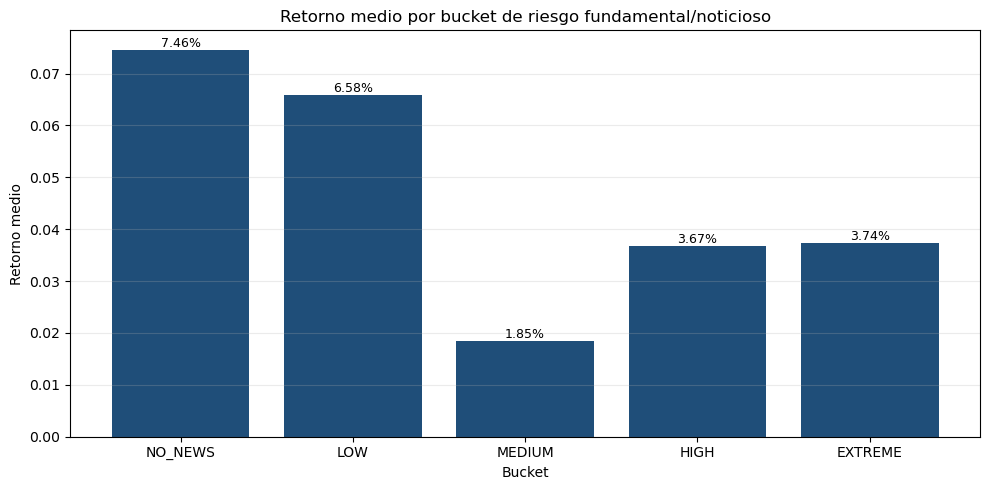

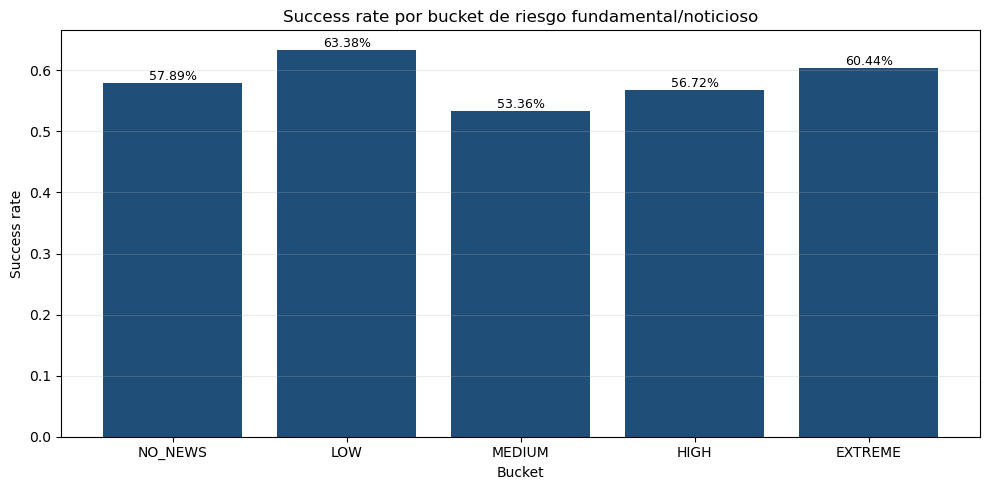

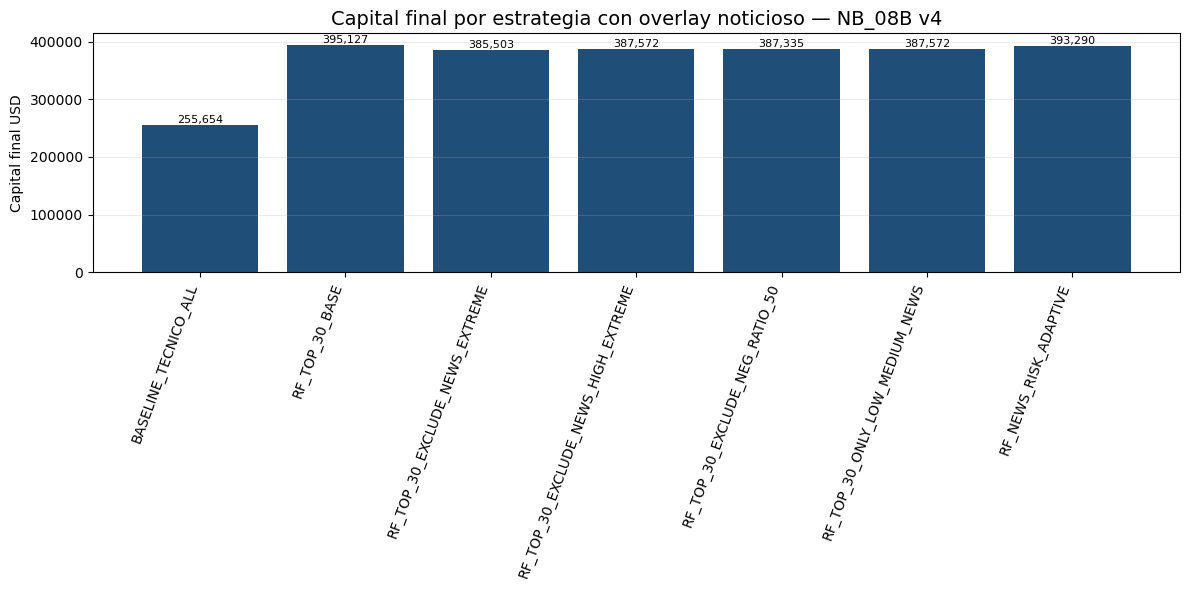

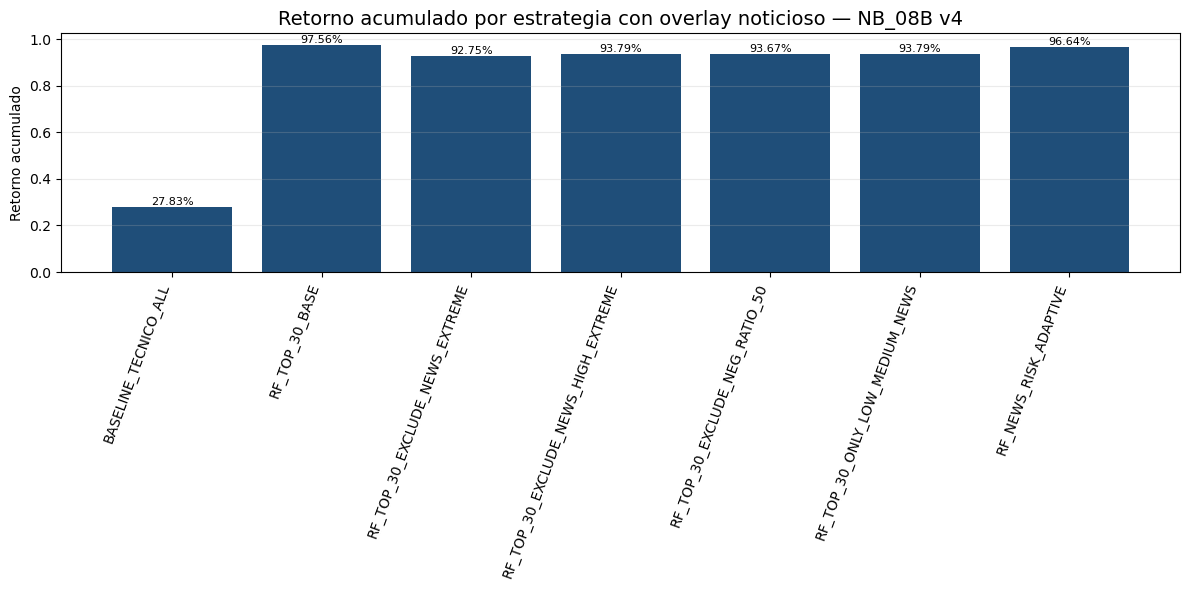

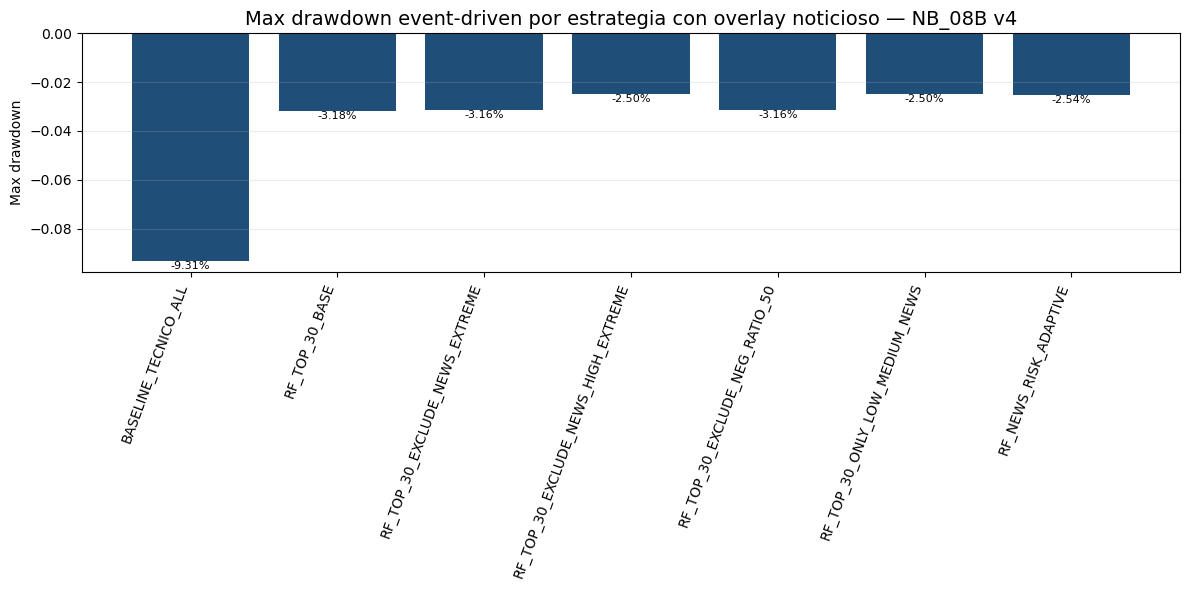

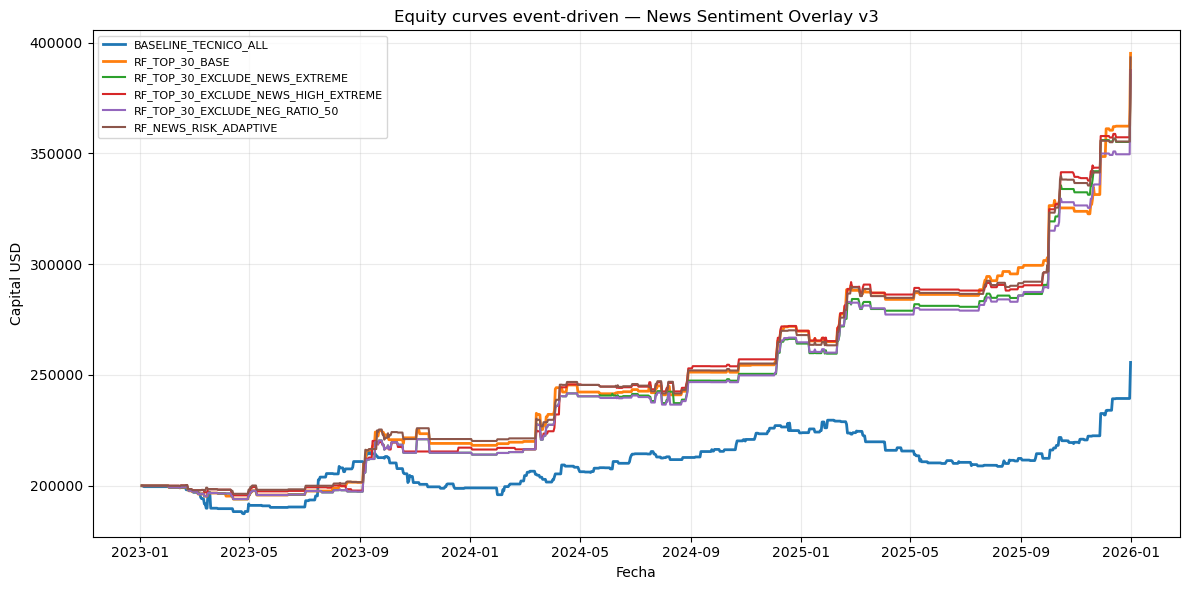

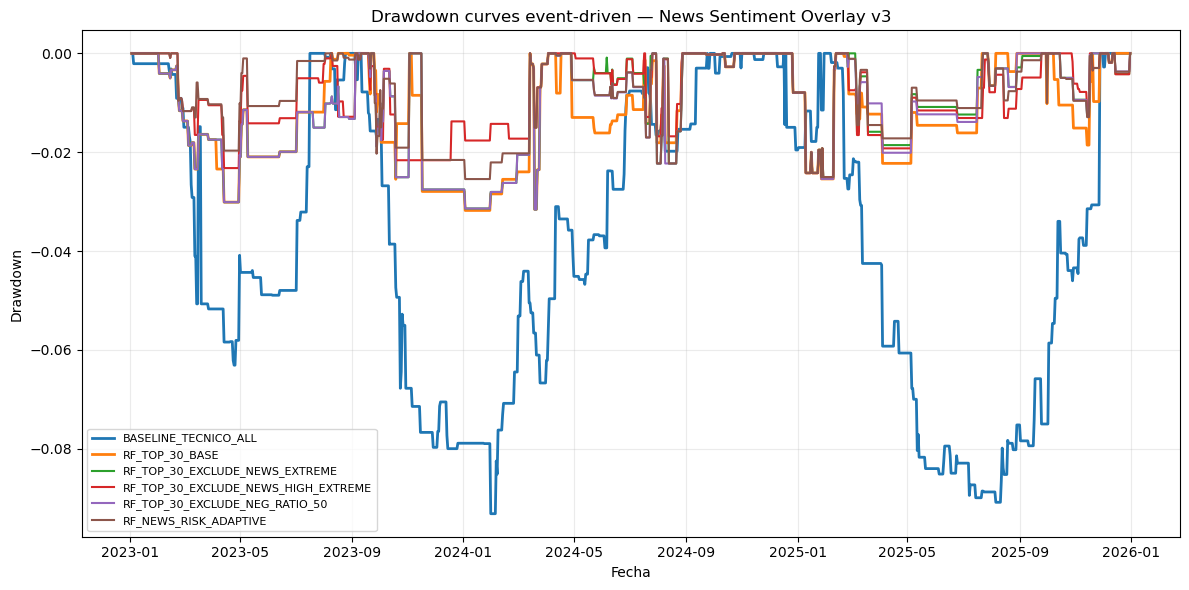

In [22]:
# ============================================================
# 21. Gráficos
# ============================================================

DARK_BLUE = "#1f4e79"

bucket_order = ["NO_NEWS", "LOW", "MEDIUM", "HIGH", "EXTREME"]
plot_bucket = news_bucket_metrics.copy()
plot_bucket["bucket_order"] = plot_bucket["fundamental_news_risk_bucket"].apply(lambda x: bucket_order.index(x) if x in bucket_order else 999)
plot_bucket = plot_bucket.sort_values("bucket_order")

plt.figure(figsize=(10, 5))
plt.bar(plot_bucket["fundamental_news_risk_bucket"], plot_bucket["mean_return"], color=DARK_BLUE)
plt.title("Retorno medio por bucket de riesgo fundamental/noticioso")
plt.ylabel("Retorno medio")
plt.xlabel("Bucket")
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(plot_bucket["mean_return"]):
    plt.text(i, v, f"{v:.2%}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_return_by_news_risk_bucket_nb08b_v4.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
plt.bar(plot_bucket["fundamental_news_risk_bucket"], plot_bucket["success_rate"], color=DARK_BLUE)
plt.title("Success rate por bucket de riesgo fundamental/noticioso")
plt.ylabel("Success rate")
plt.xlabel("Bucket")
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(plot_bucket["success_rate"]):
    plt.text(i, v, f"{v:.2%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "success_rate_by_news_risk_bucket_nb08b_v4.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

def bar_metric(df, metric, title, ylabel, filename, pct=False):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df["strategy"], df[metric], color=DARK_BLUE)
    plt.title(title, fontsize=14)
    plt.ylabel(ylabel)
    plt.xticks(rotation=70, ha="right")
    plt.grid(axis="y", alpha=0.25)
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            label = f"{h:.2%}" if pct else f"{h:,.0f}"
            plt.text(b.get_x()+b.get_width()/2, h, label, ha="center", va="bottom" if h >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

bar_metric(portfolio_metrics, "final_capital", "Capital final por estrategia con overlay noticioso — NB_08B v4", "Capital final USD", "final_capital_news_overlay_nb08b_v4.png")
bar_metric(portfolio_metrics, "total_return", "Retorno acumulado por estrategia con overlay noticioso — NB_08B v4", "Retorno acumulado", "total_return_news_overlay_nb08b_v4.png", pct=True)
bar_metric(portfolio_metrics, "max_drawdown_event", "Max drawdown event-driven por estrategia con overlay noticioso — NB_08B v4", "Max drawdown", "max_drawdown_news_overlay_nb08b_v4.png", pct=True)

# Equity curves
key_strategies = [
    "BASELINE_TECNICO_ALL",
    "RF_TOP_30_BASE",
    "RF_TOP_30_EXCLUDE_NEWS_EXTREME",
    "RF_TOP_30_EXCLUDE_NEWS_HIGH_EXTREME",
    "RF_TOP_30_EXCLUDE_NEG_RATIO_50",
    "RF_NEWS_RISK_ADAPTIVE",
]

if not portfolio_equity.empty:
    eq = portfolio_equity.copy()
    eq["date"] = pd.to_datetime(eq["date"])
    idx = pd.date_range(eq["date"].min(), eq["date"].max(), freq="D")

    equity_panel = []
    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = eq[eq["strategy"] == strategy].sort_values("date")
        if sub.empty:
            continue
        s = sub.groupby("date")["equity"].last().reindex(idx).ffill().fillna(INITIAL_CAPITAL)
        equity_panel.append(pd.DataFrame({"date": idx, "strategy": strategy, "equity": s.values}))
        plt.plot(idx, s.values, label=strategy, linewidth=2 if strategy in ["BASELINE_TECNICO_ALL", "RF_TOP_30_BASE"] else 1.5)

    plt.title("Equity curves event-driven — News Sentiment Overlay v3")
    plt.ylabel("Capital USD")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(EQUITY_DIR / "equity_curves_news_overlay_nb08b_v4.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    equity_panel = pd.concat(equity_panel, ignore_index=True)
    equity_panel.to_csv(OUTPUT_DIR / "equity_panel_news_overlay_nb08b_v4.csv", index=False)

    dd_panel = []
    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = equity_panel[equity_panel["strategy"] == strategy].copy()
        if sub.empty:
            continue
        sub["drawdown"] = sub["equity"] / sub["equity"].cummax() - 1
        dd_panel.append(sub)
        plt.plot(sub["date"], sub["drawdown"], label=strategy, linewidth=2 if strategy in ["BASELINE_TECNICO_ALL", "RF_TOP_30_BASE"] else 1.5)

    plt.title("Drawdown curves event-driven — News Sentiment Overlay v3")
    plt.ylabel("Drawdown")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(DRAWDOWN_DIR / "drawdown_curves_news_overlay_nb08b_v4.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    dd_panel = pd.concat(dd_panel, ignore_index=True)
    dd_panel.to_csv(OUTPUT_DIR / "drawdown_panel_news_overlay_nb08b_v4.csv", index=False)

In [23]:
# ============================================================
# 22. Interpretación preliminar

# ============================================================

best_return = portfolio_metrics.sort_values("final_capital", ascending=False).iloc[0]
best_drawdown = portfolio_metrics.sort_values("max_drawdown_event", ascending=False).iloc[0]

rf_base = portfolio_metrics[portfolio_metrics["strategy"] == "RF_TOP_30_BASE"].iloc[0]

coverage_total = nf["signal_id"].nunique()
coverage_any = int((nf["total_news_count_30d_pre"] > 0).sum())
coverage_company = int((nf["company_news_count_30d_pre"] > 0).sum())
coverage_macro = int((nf["macro_news_count_30d_pre"] > 0).sum())

interpretation = f"""# Interpretación preliminar NB_08B v4 — Fundamental News Sentiment Overlay

## Objetivo
Evaluar si GDELT + FinBERT aporta información fundamental/noticiosa incremental sobre la estrategia RF_TOP_30.

## Correcciones v3
- Normalización fuerte de signal_id.
- Ventana ampliada a t-{PRE_WINDOW_DAYS} a t-1.
- Consultas de compañía simplificadas.
- Consultas macro separadas por tópico.
- Diagnóstico de cobertura.

## Cobertura de noticias
- Señales RF_TOP_30: {coverage_total}
- Con cualquier noticia: {coverage_any}
- Con noticias company-specific: {coverage_company}
- Con noticias macro: {coverage_macro}

## Baseline técnico
- Capital final: {baseline['final_capital']:,.2f} USD.
- Retorno acumulado: {baseline['total_return']:.2%}.
- Max drawdown: {baseline['max_drawdown_event']:.2%}.

## RF_TOP_30_BASE
- Capital final: {rf_base['final_capital']:,.2f} USD.
- Retorno acumulado: {rf_base['total_return']:.2%}.
- Max drawdown: {rf_base['max_drawdown_event']:.2%}.
- Trades ejecutados: {int(rf_base['entered_trades'])}.

## Mejor estrategia por capital final
- Estrategia: {best_return['strategy']}.
- Capital final: {best_return['final_capital']:,.2f} USD.
- Retorno acumulado: {best_return['total_return']:.2%}.
- Max drawdown: {best_return['max_drawdown_event']:.2%}.

## Estrategia con menor drawdown
- Estrategia: {best_drawdown['strategy']}.
- Max drawdown: {best_drawdown['max_drawdown_event']:.2%}.
- Capital final: {best_drawdown['final_capital']:,.2f} USD.

## Lectura preliminar
Si las estrategias de overlay noticioso mejoran frente a RF_TOP_30_BASE, FinBERT/GDELT muestran valor incremental.
Si no mejoran, el resultado sigue siendo útil: bajo esta fuente, ventana y agregación, el sentimiento noticioso previo no aporta mejora robusta frente al ranking técnico-supervisado.

## Advertencia
La cobertura de noticias es un resultado crítico. Si sigue siendo baja, las conclusiones deben formularse como exploratorias.
"""

print(interpretation)

with open(OUTPUT_DIR / "interpretacion_preliminar_nb08b_v4.md", "w", encoding="utf-8") as f:
    f.write(interpretation)

# Interpretación preliminar NB_08B v4 — Fundamental News Sentiment Overlay

## Objetivo
Evaluar si GDELT + FinBERT aporta información fundamental/noticiosa incremental sobre la estrategia RF_TOP_30.

## Correcciones v3
- Normalización fuerte de signal_id.
- Ventana ampliada a t-30 a t-1.
- Consultas de compañía simplificadas.
- Consultas macro separadas por tópico.
- Diagnóstico de cobertura.

## Cobertura de noticias
- Señales RF_TOP_30: 980
- Con cualquier noticia: 904
- Con noticias company-specific: 335
- Con noticias macro: 848

## Baseline técnico
- Capital final: 255,653.88 USD.
- Retorno acumulado: 27.83%.
- Max drawdown: -9.31%.

## RF_TOP_30_BASE
- Capital final: 395,127.30 USD.
- Retorno acumulado: 97.56%.
- Max drawdown: -3.18%.
- Trades ejecutados: 218.

## Mejor estrategia por capital final
- Estrategia: RF_TOP_30_BASE.
- Capital final: 395,127.30 USD.
- Retorno acumulado: 97.56%.
- Max drawdown: -3.18%.

## Estrategia con menor drawdown
- Estrategia: RF_TOP_30_EXCLUDE_NE

In [24]:
# ============================================================
# 23. Listado de outputs
# ============================================================

print("Outputs generados en:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(OUTPUT_DIR))

Outputs generados en: /Users/rbr/TFM_MVP/JUNIO/NB_08B/outputs_nb08b_v4
- cache/finbert_news_sentiment_v4_cache.csv
- cache/gdelt_company_news_rf_top30_v4_cache.csv
- cache/gdelt_macro_news_v4_cache.csv
- cache/ticker_company_names_cache.csv
- drawdown_panel_news_overlay_nb08b_v4.csv
- equity_panel_news_overlay_nb08b_v4.csv
- figures/drawdowns/drawdown_curves_news_overlay_nb08b_v4.png
- figures/equity_curves/equity_curves_news_overlay_nb08b_v4.png
- figures/final_capital_news_overlay_nb08b_v4.png
- figures/max_drawdown_news_overlay_nb08b_v4.png
- figures/mean_return_by_news_risk_bucket_nb08b_v4.png
- figures/success_rate_by_news_risk_bucket_nb08b_v4.png
- figures/total_return_news_overlay_nb08b_v4.png
- interpretacion_preliminar_nb08b_v4.md
- news_raw_gdelt_for_finbert_nb08b_v4.csv
- news_sentiment_finbert_nb08b_v4.csv
- portfolio_news_overlay_equity_nb08b_v4.csv
- portfolio_news_overlay_skipped_nb08b_v4.csv
- portfolio_news_overlay_trades_nb08b_v4.csv
- tables/fundamental_news_risk_sco